> **Historical study — preserved evidence.** This notebook records the original P3 exploration and outputs. Workstation paths and transient runtime metadata were redacted for publication. The maintained, typed implementation lives in `src/off_quality`; the historical notebook is retained to demonstrate the breadth and evolution of the work.

In [ ]:
import matplotlib.figure as fig
from matplotlib.patches import Polygon
import pandas as pa
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
from sklearn.experimental import enable_iterative_imputer  # noqa
from sklearn.impute import IterativeImputer
# from sklearn.datasets import fetch_california_housing
# from sklearn.impute import SimpleImputer
# from sklearn.linear_model import BayesianRidge
# from sklearn.tree import DecisionTreeRegressor
# from sklearn.ensemble import ExtraTreesRegressor
# from sklearn.neighbors import KNeighborsRegressor
# from sklearn.pipeline import make_pipeline
# from sklearn.model_selection import cross_val_score

In [ ]:

off = pa.read_csv('../fr.openfoodfacts.org.products/fr.openfoodfacts.org.products.csv', sep='\t')

In [3]:
# off.columns = [c.replace("-", "_") for c in list(off.columns)]
off.columns = off.columns.str.replace('-','_')

In [4]:
off.columns.values

array(['code', 'url', 'creator', 'created_t', 'created_datetime',
       'last_modified_t', 'last_modified_datetime', 'product_name',
       'generic_name', 'quantity', 'packaging', 'packaging_tags',
       'brands', 'brands_tags', 'categories', 'categories_tags',
       'categories_fr', 'origins', 'origins_tags', 'manufacturing_places',
       'manufacturing_places_tags', 'labels', 'labels_tags', 'labels_fr',
       'emb_codes', 'emb_codes_tags', 'first_packaging_code_geo',
       'cities', 'cities_tags', 'purchase_places', 'stores', 'countries',
       'countries_tags', 'countries_fr', 'ingredients_text', 'allergens',
       'allergens_fr', 'traces', 'traces_tags', 'traces_fr',
       'serving_size', 'no_nutriments', 'additives_n', 'additives',
       'additives_tags', 'additives_fr', 'ingredients_from_palm_oil_n',
       'ingredients_from_palm_oil', 'ingredients_from_palm_oil_tags',
       'ingredients_that_may_be_from_palm_oil_n',
       'ingredients_that_may_be_from_palm_oil',
   

In [5]:
off.shape

(320772, 162)

### isnull & sum
Profitons du fait de voir des `NaN` pour utiliser la combinaison de commande pratique de 🐼 `.isnull()` & `sum()`.
> [Isnull](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.isnull.html?highlight=isnull#pandas.DataFrame.isnull) nous retourne un tableau de booléens de même taille que notre Dataframe Les valeurs `NaN`, telles que None ou [numpy.NaN](https://numpy.org/doc/stable/reference/constants.html?highlight=nan#numpy.NaN), sont mappées aux valeurs `True`. Tout le reste est mappé sur des valeurs ``False``.
> [Sum](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.sum.html?highlight=sum#pandas.DataFrame.sum) Renvoie la somme des valeurs sur l'axe demandé.
> > *par defaut : `DataFrame.sum(axis=None, skipna=None, level=None, numeric_only=None, min_count=0, **kwargs)`*

In [6]:
off.isnull().sum()

code                           23
url                            23
creator                         2
created_t                       3
created_datetime                9
                            ...  
carbon_footprint_100g      320504
nutrition_score_fr_100g     99562
nutrition_score_uk_100g     99562
glycemic_index_100g        320772
water_hardness_100g        320772
Length: 162, dtype: int64

In [7]:
off.nutrition_grade_fr.isnull().sum()

99562

### dtypes
Affichons le types de nos colonnes `.dtypes`.
> [DTypes](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.dtypes.html?highlight=dtypes#pandas.DataFrame.dtypes) Renvoie les dtypes dans le DataFrame.

In [8]:
off.dtypes

code                        object
url                         object
creator                     object
created_t                   object
created_datetime            object
                            ...   
carbon_footprint_100g      float64
nutrition_score_fr_100g    float64
nutrition_score_uk_100g    float64
glycemic_index_100g        float64
water_hardness_100g        float64
Length: 162, dtype: object

> dans le cadre de mon projet la recherche d'additif

In [9]:
off.where(off.additives.str.contains('E250',flags=re.IGNORECASE, regex=True)).dropna(subset=['additives']).head(1)

,code,url,creator,created_t,created_datetime,last_modified_t,last_modified_datetime,product_name,generic_name,quantity,...,ph_100g,fruits_vegetables_nuts_100g,collagen_meat_protein_ratio_100g,cocoa_100g,chlorophyl_100g,carbon_footprint_100g,nutrition_score_fr_100g,nutrition_score_uk_100g,glycemic_index_100g,water_hardness_100g
894,90100,http://world-fr.openfoodfacts.org/produit/0009...,gildubs,1461687702,2016-04-26T16:21:42Z,1491141108,2017-04-02T13:51:48Z,Pulled Pork & Chorizo Feijoada,"Feijoada brésilienne au porc, haricots noirs, ...",400 g,...,NaN,NaN,NaN,NaN,NaN,NaN,-4.0,-4.0,NaN,NaN


In [10]:
off.head()

,code,url,creator,created_t,created_datetime,last_modified_t,last_modified_datetime,product_name,generic_name,quantity,...,ph_100g,fruits_vegetables_nuts_100g,collagen_meat_protein_ratio_100g,cocoa_100g,chlorophyl_100g,carbon_footprint_100g,nutrition_score_fr_100g,nutrition_score_uk_100g,glycemic_index_100g,water_hardness_100g
0,3087,http://world-fr.openfoodfacts.org/produit/0000...,openfoodfacts-contributors,1474103866,2016-09-17T09:17:46Z,1474103893,2016-09-17T09:18:13Z,Farine de blé noir,NaN,1kg,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,4530,http://world-fr.openfoodfacts.org/produit/0000...,usda-ndb-import,1489069957,2017-03-09T14:32:37Z,1489069957,2017-03-09T14:32:37Z,Banana Chips Sweetened (Whole),NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,14.0,14.0,NaN,NaN
2,4559,http://world-fr.openfoodfacts.org/produit/0000...,usda-ndb-import,1489069957,2017-03-09T14:32:37Z,1489069957,2017-03-09T14:32:37Z,Peanuts,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,NaN,NaN
3,16087,http://world-fr.openfoodfacts.org/produit/0000...,usda-ndb-import,1489055731,2017-03-09T10:35:31Z,1489055731,2017-03-09T10:35:31Z,Organic Salted Nut Mix,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,12.0,12.0,NaN,NaN
4,16094,http://world-fr.openfoodfacts.org/produit/0000...,usda-ndb-import,1489055653,2017-03-09T10:34:13Z,1489055653,2017-03-09T10:34:13Z,Organic Polenta,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [11]:
# Créer une nouvelle fonction qui détermine si la valeur en paramètre est manquante:
def mean_col_missing(x):
    return x.isnull().mean()

In [12]:
# selection de colonne sur un seuil minimum de donnée manquante
def select_threshold(data_st, seuil):
    data_st = data_st[data_st.apply(mean_col_missing).where(data_st.apply(mean_col_missing)< seuil).dropna().keys()].copy()
    return data_st

In [13]:
# On applique cette fonction pour chaque colonne:
print("Moyennes valeurs manquantes par colonne:")
off.apply(mean_col_missing, axis=0) #axis=0 définit que la fonction sera bien appliquée sur chaque colonne

Moyennes valeurs manquantes par colonne:


code                       0.000072
url                        0.000072
creator                    0.000006
created_t                  0.000009
created_datetime           0.000028
                             ...   
carbon_footprint_100g      0.999165
nutrition_score_fr_100g    0.310382
nutrition_score_uk_100g    0.310382
glycemic_index_100g        1.000000
water_hardness_100g        1.000000
Length: 162, dtype: float64

In [14]:
# On applique nos fonctions pour selectionner seulement dont les données manquantes sont inferieur a un seuil
off_clean_col = select_threshold(off,0.52)
off_clean_col

,code,url,creator,created_t,created_datetime,last_modified_t,last_modified_datetime,product_name,brands,brands_tags,...,fat_100g,saturated_fat_100g,carbohydrates_100g,sugars_100g,fiber_100g,proteins_100g,salt_100g,sodium_100g,nutrition_score_fr_100g,nutrition_score_uk_100g
0,3087,http://world-fr.openfoodfacts.org/produit/0000...,openfoodfacts-contributors,1474103866,2016-09-17T09:17:46Z,1474103893,2016-09-17T09:18:13Z,Farine de blé noir,Ferme t'y R'nao,ferme-t-y-r-nao,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,4530,http://world-fr.openfoodfacts.org/produit/0000...,usda-ndb-import,1489069957,2017-03-09T14:32:37Z,1489069957,2017-03-09T14:32:37Z,Banana Chips Sweetened (Whole),NaN,NaN,...,28.57,28.57,64.29,14.29,3.6,3.57,0.00000,0.000,14.0,14.0
2,4559,http://world-fr.openfoodfacts.org/produit/0000...,usda-ndb-import,1489069957,2017-03-09T14:32:37Z,1489069957,2017-03-09T14:32:37Z,Peanuts,Torn & Glasser,torn-glasser,...,17.86,0.00,60.71,17.86,7.1,17.86,0.63500,0.250,0.0,0.0
3,16087,http://world-fr.openfoodfacts.org/produit/0000...,usda-ndb-import,1489055731,2017-03-09T10:35:31Z,1489055731,2017-03-09T10:35:31Z,Organic Salted Nut Mix,Grizzlies,grizzlies,...,57.14,5.36,17.86,3.57,7.1,17.86,1.22428,0.482,12.0,12.0
4,16094,http://world-fr.openfoodfacts.org/produit/0000...,usda-ndb-import,1489055653,2017-03-09T10:34:13Z,1489055653,2017-03-09T10:34:13Z,Organic Polenta,Bob's Red Mill,bob-s-red-mill,...,1.43,NaN,77.14,NaN,5.7,8.57,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
320767,9948282780603,http://world-fr.openfoodfacts.org/produit/9948...,openfoodfacts-contributors,1490631299,2017-03-27T16:14:59Z,1491244498,2017-04-03T18:34:58Z,Tomato & ricotta,Panzani,panzani,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
320768,99567453,http://world-fr.openfoodfacts.org/produit/9956...,usda-ndb-import,1489059076,2017-03-09T11:31:16Z,1491244499,2017-04-03T18:34:59Z,"Mint Melange Tea A Blend Of Peppermint, Lemon ...",Trader Joe's,trader-joe-s,...,0.00,0.00,0.00,0.00,0.0,0.00,0.00000,0.000,0.0,0.0
320769,9970229501521,http://world-fr.openfoodfacts.org/produit/9970...,tomato,1422099377,2015-01-24T11:36:17Z,1491244499,2017-04-03T18:34:59Z,乐吧泡菜味薯片,乐吧,乐吧,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
320770,9980282863788,http://world-fr.openfoodfacts.org/produit/9980...,openfoodfacts-contributors,1492340089,2017-04-16T10:54:49Z,1492340089,2017-04-16T10:54:49Z,Tomates aux Vermicelles,Knorr,knorr,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [15]:
off_clean_col.countries.unique()

array(['en:FR', 'US', 'France', ..., 'Malaisie', 'en:HK, en:france',
       'Hong Kong,China'], dtype=object)

### Series.str
> [Str](https://pandas.pydata.org/docs/reference/api/pandas.Series.str.html)
Fonctions de chaîne vectorisées pour les séries et les index.
Les NA restent NA à moins qu'ils ne soient traités autrement par une méthode particulière. Inspiré des méthodes de chaîne de Python, avec une certaine inspiration du package stringr de R
>[contains](https://pandas.pydata.org/docs/reference/api/pandas.Series.str.contains.html)
Teste si un motif ou une expression régulière est contenu dans une chaîne d'une série ou d'un index.

ci-dessous on utilisera les fonctions pour ne retenir que les individus dont la diffusion se situe en France

In [16]:
off_fr = off_clean_col.where(off_clean_col.countries.str.contains('fr', flags=re.IGNORECASE, regex=True)).dropna(subset=['countries']).copy()

In [17]:
# vérifions
off_fr.countries.unique()

array(['en:FR', 'France', 'France, US', 'France,Royaume-Uni', 'UK,France',
       'France,Belgique,Pays-Bas,Royaume-Uni', 'France,United Kingdom',
       'France,UK', 'Royaume-Uni,France', 'en:AU, en:france',
       'France,Suisse,États-Unis,Canada', 'États-Unis, en:france, US',
       'en:RE, en:france', 'United States, en:france',
       'Deutschland, en:france', 'Belgique,France', 'en:FR, US',
       'Belgique,France,Pays-Bas,Royaume-Uni', 'France,United States',
       'France, Suisse', 'en:FR, Suisse', 'France,États-Unis',
       'en:US, en:france', 'France,États-Unis,Suisse',
       'Frankreich,Deutschland', 'France,Italie',
       'United Kingdom, en:france', 'Belgique, en:france',
       'United Kingdom,France', 'France,United Kingdom,United States',
       'United States, en:france, en:switzerland', 'France,Switzerland',
       'Australia,France,United Kingdom', 'France,United Kingdom, US',
       'France,Belgique,Royaume-Uni,Pays-Bas', 'UK,France,US',
       'en:CA, en:france

In [18]:
# regardons plus precisement le type des données dans nos colonnes et nous constaterons une dissonance entre cette information et celle sur le type des colonnes plus haut, dut a des erreurs lexical
for col in off_fr:
    print(f"colonne {col} : {type(off_fr[col][0])}")

colonne code : <class 'int'>
colonne url : <class 'str'>
colonne creator : <class 'str'>
colonne created_t : <class 'int'>
colonne created_datetime : <class 'str'>
colonne last_modified_t : <class 'int'>
colonne last_modified_datetime : <class 'str'>
colonne product_name : <class 'str'>
colonne brands : <class 'str'>
colonne brands_tags : <class 'str'>
colonne countries : <class 'str'>
colonne countries_tags : <class 'str'>
colonne countries_fr : <class 'str'>
colonne ingredients_text : <class 'float'>
colonne serving_size : <class 'float'>
colonne additives_n : <class 'numpy.float64'>
colonne additives : <class 'float'>
colonne additives_tags : <class 'float'>
colonne additives_fr : <class 'float'>
colonne ingredients_from_palm_oil_n : <class 'numpy.float64'>
colonne ingredients_that_may_be_from_palm_oil_n : <class 'numpy.float64'>
colonne nutrition_grade_fr : <class 'float'>
colonne states : <class 'str'>
colonne states_tags : <class 'str'>
colonne states_fr : <class 'str'>
colonne e

In [19]:
off_fr.shape

(98468, 36)

In [20]:
off_fr.isnull().sum()

code                                           0
url                                            0
creator                                        0
created_t                                      0
created_datetime                               1
last_modified_t                                0
last_modified_datetime                         0
product_name                                7182
brands                                     12012
brands_tags                                12016
countries                                      0
countries_tags                                 0
countries_fr                                   0
ingredients_text                           44967
serving_size                               72087
additives_n                                44967
additives                                  44981
additives_tags                             67995
additives_fr                               67995
ingredients_from_palm_oil_n                44967
ingredients_that_may

la fonction ci-dessous va controler et convertir nos donnees pour corriger les erreurs lexicales de type numerique entiere.
Sachant qu'un [code barre](https://fr.wikipedia.org/wiki/Code-barres_EAN) répond à une norme.

In [21]:
def numeric_lexical_error(x):
    if type(x) is int:
        y = x
    elif len(x)<19:
        y = pa.to_numeric(x, downcast='integer')
    else:
        y=np.nan
    return y

In [22]:
code_numeric = off_fr.code.apply(numeric_lexical_error)

In [23]:
off_fr.apply(lambda x:x.describe())

,code,url,creator,created_t,created_datetime,last_modified_t,last_modified_datetime,product_name,brands,brands_tags,...,fat_100g,saturated_fat_100g,carbohydrates_100g,sugars_100g,fiber_100g,proteins_100g,salt_100g,sodium_100g,nutrition_score_fr_100g,nutrition_score_uk_100g
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1.300000,0.300000,4.000000,1.000000,0.000000,1.800000,0.080000,0.031496,1.000000,0.000000
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,6.800000,2.000000,14.500000,4.100000,1.390000,6.000000,0.558800,0.220000,9.000000,7.000000
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,21.000000,7.400000,53.000000,17.800000,3.200000,11.000000,1.244600,0.490000,15.000000,16.000000
count,98468.0,98468,98468,9.846800e+04,98467,9.846800e+04,98468,91286,86456,86452,...,47677.000000,62412.000000,47245.000000,62555.000000,45747.000000,64354.000000,62613.000000,62610.000000,61451.000000,61451.000000
freq,2.0,1,29195,6.000000e+00,6,1.500000e+01,15,62,2838,2977,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
max,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,380.000000,210.000000,190.000000,105.000000,178.000000,100.000000,211.000000,83.000000,40.000000,36.000000
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,13.340016,5.426280,27.749530,13.431192,2.559144,7.754553,1.160270,0.456820,8.684757,8.364941
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.000000,0.000000,0.000000,-0.100000,0.000000,0.000000,0.000000,0.000000,-15.000000,-15.000000
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,16.939263,8.536277,27.411755,19.087523,4.633990,7.887170,4.308534,1.696255,9.046268,9.384760
top,24600.0,http://world-fr.openfoodfacts.org/produit/0000...,openfoodfacts-contributors,1.415015e+09,2014-11-03T11:38:51Z,1.439142e+09,2015-08-09T17:35:56Z,Huile d'olive vierge extra,Carrefour,carrefour,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [24]:
code_numeric.describe()

count    9.845900e+04
mean     3.910007e+12
std      1.830766e+13
min      1.000000e+00
25%      3.222476e+12
50%      3.347440e+12
75%      3.760057e+12
max      5.410000e+15
Name: code, dtype: float64

In [25]:
# recherche de code trop long remplcer par de NaN et recupération des index
i_code_numeric = code_numeric[code_numeric.isna()].index
off_code_oversize = off.iloc[i_code_numeric]
select_threshold(off_code_oversize, 0.50) # aucune quantitative ---> suppression

,code,url,creator,created_t,created_datetime,last_modified_t,last_modified_datetime,product_name,countries,countries_tags,countries_fr,states,states_tags,states_fr
111061,01032580700553083103005000171606011016123,http://world-fr.openfoodfacts.org/produit/0103...,date-limite-app,1463906816,2016-05-22T08:46:56Z,1463926563,2016-05-22T14:16:03Z,Fromage blanc,France,en:france,France,"en:to-be-completed, en:nutrition-facts-to-be-c...","en:to-be-completed,en:nutrition-facts-to-be-co...","A compléter,Informations nutritionnelles à com..."
111074,010503886234612215160606,http://world-fr.openfoodfacts.org/produit/0105...,date-limite-app,1463907769,2016-05-22T09:02:49Z,1463907769,2016-05-22T09:02:49Z,NaN,en:FR,en:france,France,"en:to-be-completed, en:nutrition-facts-to-be-c...","en:to-be-completed,en:nutrition-facts-to-be-co...","A compléter,Informations nutritionnelles à com..."
111075,010503886235612115160603,http://world-fr.openfoodfacts.org/produit/0105...,date-limite-app,1463907723,2016-05-22T09:02:03Z,1463907724,2016-05-22T09:02:04Z,NaN,en:FR,en:france,France,"en:to-be-completed, en:nutrition-facts-to-be-c...","en:to-be-completed,en:nutrition-facts-to-be-co...","A compléter,Informations nutritionnelles à com..."
111560,0135564201190391716060410160604,http://world-fr.openfoodfacts.org/produit/0135...,date-limite-app,1463907952,2016-05-22T09:05:52Z,1463911641,2016-05-22T10:07:21Z,Yaourt au lait entier sucré infusé à la gousse...,France,en:france,France,"en:to-be-completed, en:nutrition-facts-to-be-c...","en:to-be-completed,en:nutrition-facts-to-be-co...","A compléter,Informations nutritionnelles à com..."
112591,01932789107079551715031730000001,http://world-fr.openfoodfacts.org/produit/0193...,jeanbono,1424980966,2015-02-26T20:02:46Z,1475522975,2016-10-03T19:29:35Z,Tripes cuisinées tomate,France,en:france,France,"en:to-be-completed, en:nutrition-facts-to-be-c...","en:to-be-completed,en:nutrition-facts-to-be-co...","A compléter,Informations nutritionnelles à com..."
112592,0194008298666105310300052215170423106284,http://world-fr.openfoodfacts.org/produit/0194...,date-limite-app,1492520064,2017-04-18T12:54:24Z,1492520064,2017-04-18T12:54:24Z,Bedford Saltufo,en:FR,en:france,France,"en:to-be-completed, en:nutrition-facts-to-be-c...","en:to-be-completed,en:nutrition-facts-to-be-co...","A compléter,Informations nutritionnelles à com..."
186282,277613356460737500000245,http://world-fr.openfoodfacts.org/produit/2776...,date-limite-app,1474129298,2016-09-17T16:21:38Z,1474129299,2016-09-17T16:21:39Z,NaN,en:FR,en:france,France,"en:to-be-completed, en:nutrition-facts-to-be-c...","en:to-be-completed,en:nutrition-facts-to-be-co...","A compléter,Informations nutritionnelles à com..."
186295,278710908920585500000295,http://world-fr.openfoodfacts.org/produit/2787...,date-limite-app,1474128898,2016-09-17T16:14:58Z,1474129029,2016-09-17T16:17:09Z,NaN,en:FR,en:france,France,"en:to-be-completed, en:nutrition-facts-to-be-c...","en:to-be-completed,en:nutrition-facts-to-be-co...","A compléter,Informations nutritionnelles à com..."
189655,3033710074617000062800,http://world-fr.openfoodfacts.org/produit/3033...,openfoodfacts-contributors,1474053413,2016-09-16T19:16:53Z,1474120111,2016-09-17T13:48:31Z,Nescafé Décaféiné Spécial Filtre,France,en:france,France,"en:to-be-completed, en:nutrition-facts-to-be-c...","en:to-be-completed,en:nutrition-facts-to-be-co...","A compléter,Informations nutritionnelles à com..."


In [26]:
off_drop_code_oversize = off_fr.drop(i_code_numeric).copy()
off_drop_code_oversize.shape

(98459, 36)

In [27]:
code_numeric.apply(lambda x: type(x))

0         <class 'float'>
46        <class 'float'>
48        <class 'float'>
106       <class 'float'>
136       <class 'float'>
               ...       
320761    <class 'float'>
320763    <class 'float'>
320764    <class 'float'>
320765    <class 'float'>
320770    <class 'float'>
Name: code, Length: 98468, dtype: object

In [28]:
off_drop_code_oversize.code.apply(lambda x: type(x))

0         <class 'int'>
46        <class 'int'>
48        <class 'int'>
106       <class 'int'>
136       <class 'int'>
              ...      
320761    <class 'str'>
320763    <class 'str'>
320764    <class 'str'>
320765    <class 'str'>
320770    <class 'str'>
Name: code, Length: 98459, dtype: object

In [29]:
# off_num_code
off_drop_code_oversize['code'] = off_drop_code_oversize['code'].apply(numeric_lexical_error)
off_drop_code_oversize.dtypes

code                                         int64
url                                         object
creator                                     object
created_t                                   object
created_datetime                            object
last_modified_t                             object
last_modified_datetime                      object
product_name                                object
brands                                      object
brands_tags                                 object
countries                                   object
countries_tags                              object
countries_fr                                object
ingredients_text                            object
serving_size                                object
additives_n                                float64
additives                                   object
additives_tags                              object
additives_fr                                object
ingredients_from_palm_oil_n    

In [30]:
off_fr = off_drop_code_oversize
off_fr.shape

(98459, 36)

In [31]:
def describe_by_columns(data_dbc):
    for key,value in data_dbc.iteritems():
        print(f"|\tcolumns name {value.name}")
        print(f"|\tcolumns dtype {value.dtype}")
        print("-"*70)
        desc = value.describe()
        if value.dtype == np.float64 or value.dtype == np.int64:
            if value.name != 'id':
                print(f"|\tcount\t\t{desc['count']}")
                print(f"|\tmean\t\t{desc['mean']}")
                print(f"|\t50%\t\t\t{desc['50%']}")
                print(f"|\tmedian\t\t{value.median()}")
                print(f"|\tvar\t\t\t{value.var()}")
                print(f"|\tvar(!biais)\t{value.var(ddof=0)}")
                print(f"|\tstd\t\t\t{value.std()}\t|")
                print(f"|\tstd(!biais)\t{value.std(ddof=0)}")
                print(f"|\tstd(desc)\t{desc['std']}")
                print(f"|\t25%\t\t\t{desc['25%']}")
                print(f"|\t75%\t\t\t{desc['75%']}")
                print(f"|\tmin\t\t\t{desc['min']}")
                print(f"|\tmax\t\t\t{desc['max']}")
                print(f"|\tskew\t\t{value.skew()}")
                print(f"|\tkurt\t\t{value.kurtosis()}")
            else:
                print("|\taucune analyse descriptive")
        elif value.dtype == object:
            print(f"|\tcount\t\t{desc['count']}")
            print(f"|\tunique\t\t{desc['unique']}")
            print(f"|\ttop\t\t\t{desc['top']}")
            print(f"|\tfreq\t\t{desc['freq']}")
        else:
            print("|\taucune analyse descriptive")
        print("="*70)

In [32]:
# apres avoir traiter les codes on les transformes en qualitative ordinal
off_fr.code.astype(str)
off_fr.code = off_fr.code.apply(lambda _:str(_))

In [33]:
describe_by_columns(off_fr)

|	columns name code
|	columns dtype object
----------------------------------------------------------------------
|	count		98459
|	unique		98452
|	top			9800895250
|	freq		2
|	columns name url
|	columns dtype object
----------------------------------------------------------------------
|	count		98459
|	unique		98459
|	top			http://world-fr.openfoodfacts.org/produit/0000000003087/farine-de-ble-noir-ferme-t-y-r-nao
|	freq		1
|	columns name creator
|	columns dtype object
----------------------------------------------------------------------
|	count		98459
|	unique		2637
|	top			openfoodfacts-contributors
|	freq		29194
|	columns name created_t
|	columns dtype object
----------------------------------------------------------------------
|	count		98459
|	unique		98063
|	top			1415014731
|	freq		6
|	columns name created_datetime
|	columns dtype object
----------------------------------------------------------------------
|	count		98458
|	unique		98024
|	top			2014-11-03T11:38:51Z
|	freq		6
|	

## Recherche des valeurs dupliquées du Dataframe

### Critère

Dans notre Data frame chaque code se doit d'être unique.
+ `.duplicated()` fonction [duplicated](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.duplicated.html?highlight=duplicated#pandas.DataFrame.duplicated) qui renvoie une série booléenne indiquant les lignes en double.
+ `.drop_duplicates()` fonction [drop_duplicates](https://pandas.pydata.org/docs/reference/api/pandas.Series.drop_duplicates.html#pandas.Series.drop_duplicates) qui renvoie la série avec les valeurs en double supprimées.
Méthode pour gérer la suppression des doublons :
 + `first` : Supprime les doublons sauf pour la première occurrence.
 + `last` : supprime les doublons à l'exception de la dernière occurrence.
 + `False` : supprimez tous les doublons.

In [34]:
off_fr[off_fr.code.duplicated()]

,code,url,creator,created_t,created_datetime,last_modified_t,last_modified_datetime,product_name,brands,brands_tags,...,fat_100g,saturated_fat_100g,carbohydrates_100g,sugars_100g,fiber_100g,proteins_100g,salt_100g,sodium_100g,nutrition_score_fr_100g,nutrition_score_uk_100g
519,24600,http://world-fr.openfoodfacts.org/produit/0002...,tacinte,1435406581,2015-06-27T12:03:01Z,1435406592,2015-06-27T12:03:12Z,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9892,11778,http://world-fr.openfoodfacts.org/produit/0011...,beniben,1474489149,2016-09-21T20:19:09Z,1491142385,2017-04-02T14:13:05Z,All Butter Reduced Fat Stem Ginger Cookies,Marks & Spencer,marks-spencer,...,13.3,7.0,70.2,35.7,2.5,6.1,0.83,0.326772,18.0,18.0
120240,635646,http://world-fr.openfoodfacts.org/produit/0635...,beniben,1474521344,2016-09-22T05:15:44Z,1491142371,2017-04-02T14:12:51Z,Chargrilled Vegetable & Basil Pesto,Marks & Spencer,marks-spencer,...,7.8,1.9,24.9,3.8,2.0,7.7,0.98,0.385827,1.0,1.0
134825,722810,http://world-fr.openfoodfacts.org/produit/0722...,ariane,1459668979,2016-04-03T07:36:19Z,1491146173,2017-04-02T15:16:13Z,Sea Salt & Balsamic Vinegar hand cooked Crisps,marks and Spencer,marks-and-spencer,...,30.4,3.2,52.8,1.9,4.6,6.7,1.83,0.720472,12.0,12.0
283605,62020000743,http://world-fr.openfoodfacts.org/produit/6202...,tacite-mass-editor,1490554697,2017-03-26T18:58:17Z,1490554697,2017-03-26T18:58:17Z,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
315440,87177756,http://world-fr.openfoodfacts.org/produit/8717...,kyzh,1429791263,2015-04-23T12:14:23Z,1488481875,2017-03-02T19:11:15Z,7up Cans 33CL,Pepsi,pepsi,...,NaN,11.0,NaN,11.0,0.0,0.0,0.04,0.015748,12.0,12.0
320747,9800895250,http://world-fr.openfoodfacts.org/produit/9800...,tacite-mass-editor,1490554697,2017-03-26T18:58:17Z,1490554697,2017-03-26T18:58:17Z,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [35]:
off_fr.where(off_fr.code == '24600').dropna(subset=['code'])

,code,url,creator,created_t,created_datetime,last_modified_t,last_modified_datetime,product_name,brands,brands_tags,...,fat_100g,saturated_fat_100g,carbohydrates_100g,sugars_100g,fiber_100g,proteins_100g,salt_100g,sodium_100g,nutrition_score_fr_100g,nutrition_score_uk_100g
46,24600,http://world-fr.openfoodfacts.org/produit/0000...,date-limite-app,1434530704,2015-06-17T08:45:04Z,1434535914,2015-06-17T10:11:54Z,Filet de bœuf,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
519,24600,http://world-fr.openfoodfacts.org/produit/0002...,tacinte,1435406581,2015-06-27T12:03:01Z,1435406592,2015-06-27T12:03:12Z,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [36]:
# keep permet d'afficher tous les doubles pas seulement les valeurs en doubles
off_fr[off_fr.duplicated(subset=['code'],keep=False)]

,code,url,creator,created_t,created_datetime,last_modified_t,last_modified_datetime,product_name,brands,brands_tags,...,fat_100g,saturated_fat_100g,carbohydrates_100g,sugars_100g,fiber_100g,proteins_100g,salt_100g,sodium_100g,nutrition_score_fr_100g,nutrition_score_uk_100g
46,24600,http://world-fr.openfoodfacts.org/produit/0000...,date-limite-app,1434530704,2015-06-17T08:45:04Z,1434535914,2015-06-17T10:11:54Z,Filet de bœuf,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
240,87177756,http://world-fr.openfoodfacts.org/produit/0000...,tacite,1433586486,2015-06-06T10:28:06Z,1433589206,2015-06-06T11:13:26Z,7Up,"7Up,Pepsico","7up,pepsico",...,0.0,0.0,10.4,10.4,NaN,0.00,0.100,0.039370,13.0,2.0
458,11778,http://world-fr.openfoodfacts.org/produit/0001...,gildubs,1490975915,2017-03-31T15:58:35Z,1490976772,2017-03-31T16:12:52Z,Stem Ginger Cookies,Marks & Spencer,marks-spencer,...,13.3,7.0,70.2,35.7,2.5,6.10,0.830,0.326772,18.0,18.0
519,24600,http://world-fr.openfoodfacts.org/produit/0002...,tacinte,1435406581,2015-06-27T12:03:01Z,1435406592,2015-06-27T12:03:12Z,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1346,9800895250,http://world-fr.openfoodfacts.org/produit/0009...,stephane,1373737996,2013-07-13T17:53:16Z,1489070521,2017-03-09T14:42:01Z,Nutella,"Nutella,Ferrero","nutella,ferrero",...,32.4,10.8,56.8,56.8,2.7,5.41,0.103,0.040500,23.0,23.0
9892,11778,http://world-fr.openfoodfacts.org/produit/0011...,beniben,1474489149,2016-09-21T20:19:09Z,1491142385,2017-04-02T14:13:05Z,All Butter Reduced Fat Stem Ginger Cookies,Marks & Spencer,marks-spencer,...,13.3,7.0,70.2,35.7,2.5,6.10,0.830,0.326772,18.0,18.0
67223,62020000743,http://world-fr.openfoodfacts.org/produit/0062...,openfoodfacts-contributors,1397141520,2014-04-10T14:52:00Z,1487521189,2017-02-19T16:19:49Z,Nutella,Ferrero,ferrero,...,NaN,2.0,NaN,11.0,1.0,1.00,10.000,3.937008,13.0,13.0
67371,635646,http://world-fr.openfoodfacts.org/produit/0063...,date-limite-app,1423916391,2015-02-14T12:19:51Z,1491150017,2017-04-02T16:20:17Z,M&S Vegetable pizza,Marks & Spencer,marks-spencer,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
80034,722810,http://world-fr.openfoodfacts.org/produit/0072...,date-limite-app,1491740672,2017-04-09T12:24:32Z,1491740698,2017-04-09T12:24:58Z,Chips vinaigre M&S,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
120240,635646,http://world-fr.openfoodfacts.org/produit/0635...,beniben,1474521344,2016-09-22T05:15:44Z,1491142371,2017-04-02T14:12:51Z,Chargrilled Vegetable & Basil Pesto,Marks & Spencer,marks-spencer,...,7.8,1.9,24.9,3.8,2.0,7.70,0.980,0.385827,1.0,1.0


In [37]:
# la fonction supprime tous les individus passés par la variable i_rows qui transmet le(s) index
def select_drop(x, i_rows):
    y = x.drop(i_rows).copy()
    return y

In [38]:
my_list = [519,9892,67371,80034,283605,315440,320747]
# print(type(my_list))
off_drop_code_dupl = off_fr.apply(select_drop, i_rows=my_list)
off_drop_code_dupl.duplicated().sum()

0

In [39]:
def list_duplicated(x):
   return x[x.duplicated()]

In [40]:
off_fr_dupl = off_drop_code_dupl.apply(list_duplicated)
off_fr_dupl.isna().sum()

code                                       98451
url                                        98451
creator                                     2636
created_t                                  98057
created_datetime                           98019
last_modified_t                            95251
last_modified_datetime                     95186
product_name                               81555
brands                                     33025
brands_tags                                28212
countries                                    660
countries_tags                               324
countries_fr                                 323
ingredients_text                           94089
serving_size                               77776
additives_n                                44978
additives                                  90557
additives_tags                             79523
additives_fr                               79523
ingredients_from_palm_oil_n                44955
ingredients_that_may

In [41]:
# façon plus élégante de faire un describe ;-)
def describe_columns(x):
    return x.describe()

In [42]:
off_drop_code_dupl.apply(describe_columns)

,code,url,creator,created_t,created_datetime,last_modified_t,last_modified_datetime,product_name,brands,brands_tags,...,fat_100g,saturated_fat_100g,carbohydrates_100g,sugars_100g,fiber_100g,proteins_100g,salt_100g,sodium_100g,nutrition_score_fr_100g,nutrition_score_uk_100g
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1.300000,0.300000,4.000000,1.000000,0.000000,1.800000,0.080000,0.031496,1.000000,0.000000
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,6.800000,2.000000,14.500000,4.080000,1.390000,6.000000,0.558800,0.220000,9.000000,7.000000
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,21.000000,7.400000,53.000000,17.800000,3.200000,11.000000,1.244600,0.490000,15.000000,16.000000
count,98452,98452,98452,9.845200e+04,98451,9.845200e+04,98452,91277,86450,86446,...,47676.000000,62410.000000,47244.000000,62553.000000,45745.000000,64352.000000,62611.000000,62608.000000,61449.000000,61449.000000
freq,1,1,29194,6.000000e+00,6,1.500000e+01,15,62,2838,2977,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
max,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,380.000000,210.000000,190.000000,105.000000,178.000000,100.000000,211.000000,83.000000,40.000000,36.000000
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,13.340017,5.426166,27.748631,13.430875,2.559201,7.754699,1.160293,0.456829,8.684551,8.364725
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.000000,0.000000,0.000000,-0.100000,0.000000,0.000000,0.000000,0.000000,-15.000000,-15.000000
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,16.939440,8.536382,27.411349,19.087618,4.634076,7.887231,4.308600,1.696281,9.046328,9.384821
top,3087,http://world-fr.openfoodfacts.org/produit/0000...,openfoodfacts-contributors,1.415015e+09,2014-11-03T11:38:51Z,1.439142e+09,2015-08-09T17:35:56Z,Huile d'olive vierge extra,Carrefour,carrefour,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [43]:
off_drop_code_dupl

,code,url,creator,created_t,created_datetime,last_modified_t,last_modified_datetime,product_name,brands,brands_tags,...,fat_100g,saturated_fat_100g,carbohydrates_100g,sugars_100g,fiber_100g,proteins_100g,salt_100g,sodium_100g,nutrition_score_fr_100g,nutrition_score_uk_100g
0,3087,http://world-fr.openfoodfacts.org/produit/0000...,openfoodfacts-contributors,1474103866,2016-09-17T09:17:46Z,1474103893,2016-09-17T09:18:13Z,Farine de blé noir,Ferme t'y R'nao,ferme-t-y-r-nao,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
46,24600,http://world-fr.openfoodfacts.org/produit/0000...,date-limite-app,1434530704,2015-06-17T08:45:04Z,1434535914,2015-06-17T10:11:54Z,Filet de bœuf,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
48,27205,http://world-fr.openfoodfacts.org/produit/0000...,tacinte,1458238630,2016-03-17T18:17:10Z,1458238638,2016-03-17T18:17:18Z,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
106,36252,http://world-fr.openfoodfacts.org/produit/0000...,tacinte,1422221701,2015-01-25T21:35:01Z,1489055667,2017-03-09T10:34:27Z,Lion Peanut x2,Sunridge,sunridge,...,20.0,12.5,70.0,57.5,2.5,2.5,0.09652,0.038,22.0,22.0
136,39259,http://world-fr.openfoodfacts.org/produit/0000...,tacinte,1422221773,2015-01-25T21:36:13Z,1473538082,2016-09-10T20:08:02Z,Twix x2,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
320761,9906410000009,http://world-fr.openfoodfacts.org/produit/9906...,agamitsudo,1373480408,2013-07-10T18:20:08Z,1451851215,2016-01-03T20:00:15Z,Roussette du Bugey (2011),Roussette du Bugey,roussette-du-bugey,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
320763,99111250,http://world-fr.openfoodfacts.org/produit/9911...,balooval,1367163039,2013-04-28T15:30:39Z,1371690556,2013-06-20T01:09:16Z,Thé vert Earl grey,Lobodis,lobodis,...,0.2,0.2,0.5,0.5,0.2,0.5,0.02540,0.010,2.0,0.0
320764,9918,http://world-fr.openfoodfacts.org/produit/9918...,woshilapin,1430167954,2015-04-27T20:52:34Z,1430167992,2015-04-27T20:53:12Z,"Cheese cake thé vert, yuzu",NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
320765,9935010000003,http://world-fr.openfoodfacts.org/produit/9935...,sebleouf,1446293229,2015-10-31T12:07:09Z,1446376839,2015-11-01T11:20:39Z,Rillette d'oie,"Sans marque,D.Lambert","sans-marque,d-lambert",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [44]:
produit = pa.DataFrame(off_drop_code_dupl.product_name)
marques = pa.DataFrame(off_drop_code_dupl.brands)
reference = produit.join(marques)
reference_dupl = reference.duplicated()
reference_dupl.sum()

10352

In [45]:
off_drop_code_dupl[reference_dupl].drop(columns=['creator','created_t','created_datetime','last_modified_t','last_modified_datetime'])

,code,url,product_name,brands,brands_tags,countries,countries_tags,countries_fr,ingredients_text,serving_size,...,fat_100g,saturated_fat_100g,carbohydrates_100g,sugars_100g,fiber_100g,proteins_100g,salt_100g,sodium_100g,nutrition_score_fr_100g,nutrition_score_uk_100g
187,9336247,http://world-fr.openfoodfacts.org/produit/0000...,NaN,NaN,NaN,France,en:france,France,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
227,50157846,http://world-fr.openfoodfacts.org/produit/0000...,NaN,NaN,NaN,en:FR,en:france,France,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
280,3001,http://world-fr.openfoodfacts.org/produit/0000...,NaN,NaN,NaN,en:FR,en:france,France,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
339,6666,http://world-fr.openfoodfacts.org/produit/0000...,NaN,NaN,NaN,en:FR,en:france,France,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
425,1000004005,http://world-fr.openfoodfacts.org/produit/0001...,NaN,NaN,NaN,France,en:france,France,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
320718,9688084817410,http://world-fr.openfoodfacts.org/produit/9688...,NaN,NaN,NaN,en:FR,en:france,France,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
320745,9800801107,http://world-fr.openfoodfacts.org/produit/9800...,NaN,NaN,NaN,en:FR,en:france,France,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
320746,9800895007,http://world-fr.openfoodfacts.org/produit/9800...,NaN,NaN,NaN,en:FR,en:france,France,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
320755,988639,http://world-fr.openfoodfacts.org/produit/988639,NaN,NaN,NaN,en:FR,en:france,France,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [46]:
i_product_dupli_nan = off_drop_code_dupl[reference_dupl].where(off_drop_code_dupl.product_name.isna()).dropna(subset=['code']).index
type(i_product_dupli_nan)

pandas.core.indexes.numeric.Int64Index

In [47]:
off_drop_prod_na = off_drop_code_dupl.apply(select_drop, i_rows=i_product_dupli_nan)
off_drop_prod_na

,code,url,creator,created_t,created_datetime,last_modified_t,last_modified_datetime,product_name,brands,brands_tags,...,fat_100g,saturated_fat_100g,carbohydrates_100g,sugars_100g,fiber_100g,proteins_100g,salt_100g,sodium_100g,nutrition_score_fr_100g,nutrition_score_uk_100g
0,3087,http://world-fr.openfoodfacts.org/produit/0000...,openfoodfacts-contributors,1474103866,2016-09-17T09:17:46Z,1474103893,2016-09-17T09:18:13Z,Farine de blé noir,Ferme t'y R'nao,ferme-t-y-r-nao,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
46,24600,http://world-fr.openfoodfacts.org/produit/0000...,date-limite-app,1434530704,2015-06-17T08:45:04Z,1434535914,2015-06-17T10:11:54Z,Filet de bœuf,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
48,27205,http://world-fr.openfoodfacts.org/produit/0000...,tacinte,1458238630,2016-03-17T18:17:10Z,1458238638,2016-03-17T18:17:18Z,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
106,36252,http://world-fr.openfoodfacts.org/produit/0000...,tacinte,1422221701,2015-01-25T21:35:01Z,1489055667,2017-03-09T10:34:27Z,Lion Peanut x2,Sunridge,sunridge,...,20.0,12.5,70.0,57.5,2.5,2.5,0.09652,0.038,22.0,22.0
136,39259,http://world-fr.openfoodfacts.org/produit/0000...,tacinte,1422221773,2015-01-25T21:36:13Z,1473538082,2016-09-10T20:08:02Z,Twix x2,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
320761,9906410000009,http://world-fr.openfoodfacts.org/produit/9906...,agamitsudo,1373480408,2013-07-10T18:20:08Z,1451851215,2016-01-03T20:00:15Z,Roussette du Bugey (2011),Roussette du Bugey,roussette-du-bugey,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
320763,99111250,http://world-fr.openfoodfacts.org/produit/9911...,balooval,1367163039,2013-04-28T15:30:39Z,1371690556,2013-06-20T01:09:16Z,Thé vert Earl grey,Lobodis,lobodis,...,0.2,0.2,0.5,0.5,0.2,0.5,0.02540,0.010,2.0,0.0
320764,9918,http://world-fr.openfoodfacts.org/produit/9918...,woshilapin,1430167954,2015-04-27T20:52:34Z,1430167992,2015-04-27T20:53:12Z,"Cheese cake thé vert, yuzu",NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
320765,9935010000003,http://world-fr.openfoodfacts.org/produit/9935...,sebleouf,1446293229,2015-10-31T12:07:09Z,1446376839,2015-11-01T11:20:39Z,Rillette d'oie,"Sans marque,D.Lambert","sans-marque,d-lambert",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [48]:
off_drop_prod_na[reference_dupl].drop(columns=['creator','created_t','created_datetime','last_modified_t','last_modified_datetime'])

<LOCAL_PATH>\AppData\Local\Temp/ipykernel_10148/1170810595.py:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  off_drop_prod_na[reference_dupl].drop(columns=['creator','created_t','created_datetime','last_modified_t','last_modified_datetime'])


,code,url,product_name,brands,brands_tags,countries,countries_tags,countries_fr,ingredients_text,serving_size,...,fat_100g,saturated_fat_100g,carbohydrates_100g,sugars_100g,fiber_100g,proteins_100g,salt_100g,sodium_100g,nutrition_score_fr_100g,nutrition_score_uk_100g
11301,14113230049,http://world-fr.openfoodfacts.org/produit/0014...,Almonds,Wonderful,wonderful,en:FR,en:france,France,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
11331,14113911702,http://world-fr.openfoodfacts.org/produit/0014...,Pistachios,Wonderful,wonderful,France,en:france,France,"Pistaches (96%), sel (2.5%), poivre (0.5%), su...",NaN,...,46.0,5.6,17.4,7.8,NaN,21.4,2.500000,0.984252,23.0,23.0
11353,14113913539,http://world-fr.openfoodfacts.org/produit/0014...,Pistachios,Wonderful,wonderful,en:FR,en:france,France,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
19572,22314010032,http://world-fr.openfoodfacts.org/produit/0022...,Crème de marrons de l'Ardèche,Clément Faugier,clement-faugier,France,en:france,France,"châtaignes (50%), sucre, marrons glacés, sirop...",50 g,...,0.8,0.2,63.6,50.2,1.9,1.3,0.010000,0.003937,11.0,11.0
19575,22314010100,http://world-fr.openfoodfacts.org/produit/0022...,Crème de marrons de l'Ardèche,Clément Faugier,clement-faugier,France,en:france,France,"châtaignes (50%), sucre, marrons glacés, sirop...",NaN,...,0.8,0.2,63.6,50.2,1.9,1.3,0.010000,0.003937,11.0,11.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
320589,9556041608251,http://world-fr.openfoodfacts.org/produit/9556...,Lait de Coco,Ayam,ayam,France,en:france,France,extrait de noix de coco d'Indonésie ou de Mala...,100 ml,...,20.0,18.0,3.4,2.7,0.5,2.1,0.050038,0.019700,12.0,12.0
320696,96095065,http://world-fr.openfoodfacts.org/produit/9609...,OBF,NaN,NaN,France,en:france,France,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
320711,9674441336144,http://world-fr.openfoodfacts.org/produit/9674...,Lardons,NaN,NaN,en:FR,en:france,France,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
320715,9680900070818,http://world-fr.openfoodfacts.org/produit/9680...,Graine couscous fin,Tipiak,tipiak,en:FR,en:france,France,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [49]:
off_drop_prod_na.apply(describe_columns)

,code,url,creator,created_t,created_datetime,last_modified_t,last_modified_datetime,product_name,brands,brands_tags,...,fat_100g,saturated_fat_100g,carbohydrates_100g,sugars_100g,fiber_100g,proteins_100g,salt_100g,sodium_100g,nutrition_score_fr_100g,nutrition_score_uk_100g
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1.300000,0.300000,4.00000,1.000000,0.000000,1.800000,0.080000,0.031496,1.000000,0.000000
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,6.800000,2.000000,14.50000,4.100000,1.320000,6.000000,0.558800,0.220000,9.000000,7.000000
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,21.000000,7.400000,53.00000,17.790000,3.200000,11.000000,1.244600,0.490000,15.000000,16.000000
count,91744,91744,91744,9.174400e+04,91743,9.174400e+04,91744,91277,85894,85890,...,47455.000000,62193.000000,47021.00000,62331.000000,45608.000000,64126.000000,62391.000000,62388.000000,61235.000000,61235.000000
freq,1,1,25858,6.000000e+00,6,1.300000e+01,13,62,2822,2961,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
max,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,380.000000,210.000000,190.00000,105.000000,178.000000,100.000000,211.000000,83.000000,40.000000,36.000000
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,13.337903,5.426713,27.74636,13.426553,2.559097,7.758652,1.161019,0.457114,8.681244,8.360676
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.000000,0.000000,0.00000,-0.100000,0.000000,0.000000,0.000000,0.000000,-15.000000,-15.000000
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,16.946067,8.542690,27.41869,19.085424,4.638751,7.891539,4.315449,1.698977,9.046859,9.385968
top,3087,http://world-fr.openfoodfacts.org/produit/0000...,openfoodfacts-contributors,1.415015e+09,2014-11-03T11:38:51Z,1.490554e+09,2017-03-26T18:53:54Z,Huile d'olive vierge extra,Carrefour,carrefour,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [50]:
produit = pa.DataFrame(off_drop_prod_na.product_name)
marques = pa.DataFrame(off_drop_prod_na.brands)
reference = produit.join(marques)

reference_dupl_all = reference.duplicated(keep=False)
reference_dupl_all.sum()

6293

In [51]:
off_fr_dupl_refer_all = off_drop_prod_na[reference_dupl_all].drop(columns=['creator',
                                                                   'created_t',
                                                                   'created_datetime',
                                                                   'last_modified_t'])
off_fr_dupl_refer_all.apply(describe_columns)

,code,url,last_modified_datetime,product_name,brands,brands_tags,countries,countries_tags,countries_fr,ingredients_text,...,fat_100g,saturated_fat_100g,carbohydrates_100g,sugars_100g,fiber_100g,proteins_100g,salt_100g,sodium_100g,nutrition_score_fr_100g,nutrition_score_uk_100g
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.500000,0.100000,2.700000,0.800000,0.000000,1.000000,0.040000,0.015748,1.000000,0.000000
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,4.000000,1.100000,10.600000,3.700000,1.200000,5.000000,0.508000,0.200000,9.000000,5.000000
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,23.000000,6.200000,52.000000,14.000000,3.100000,9.000000,1.200000,0.472441,15.000000,16.000000
count,6293,6293,6293,6293,5444,5444,6293,6293,6293,3803,...,3504.000000,4115.000000,3498.000000,4121.000000,2790.000000,4233.000000,4134.000000,4134.000000,4057.000000,4057.000000
freq,1,1,4,38,350,350,4955,5920,5920,16,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
max,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,100.000000,100.000000,100.000000,100.000000,45.300000,90.000000,100.000000,39.370079,32.000000,32.000000
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,14.177372,4.918905,25.149055,13.576691,2.108110,7.093539,1.193474,0.469871,8.685482,7.961055
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-14.000000,-14.000000
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,20.120249,8.462496,28.245890,20.436598,3.060993,7.777140,5.553630,2.186468,9.219393,9.617280
top,886100252,http://world-fr.openfoodfacts.org/produit/0000...,2017-04-09T07:34:17Z,Nutella,Auchan,auchan,France,en:france,France,Eau minérale naturelle,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [52]:
i_additives_na = off_fr_dupl_refer_all.where(off_fr_dupl_refer_all.additives.isna()).dropna(subset=['code']).index
off_fr_additives_dup_all = off_fr_dupl_refer_all.apply(select_drop,i_rows=i_additives_na)
off_fr_additives_dup_all.apply(describe_columns)

,code,url,last_modified_datetime,product_name,brands,brands_tags,countries,countries_tags,countries_fr,ingredients_text,...,fat_100g,saturated_fat_100g,carbohydrates_100g,sugars_100g,fiber_100g,proteins_100g,salt_100g,sodium_100g,nutrition_score_fr_100g,nutrition_score_uk_100g
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.50000,0.100000,2.600000,0.800000,0.100000,1.100000,0.050000,0.019685,1.000000,0.000000
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,4.00000,1.100000,10.600000,3.500000,1.500000,5.000000,0.590000,0.232283,9.000000,5.000000
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,22.82500,6.325000,51.975000,12.175000,3.400000,9.000000,1.270000,0.500000,15.000000,16.000000
count,3802,3802,3802,3802,3798,3798,3802,3802,3802,3802,...,3204.00000,3140.000000,3198.000000,3146.000000,1931.000000,3253.000000,3154.000000,3154.000000,3095.000000,3095.000000
freq,1,1,2,26,216,216,3495,3502,3502,16,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
max,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,100.00000,87.000000,100.000000,100.000000,45.300000,67.000000,100.000000,39.370079,32.000000,32.000000
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,14.13432,4.888954,24.688591,12.749696,2.307037,7.095057,1.183843,0.466079,8.636834,7.866236
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-14.000000,-14.000000
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,20.08704,8.352898,27.988566,19.759775,3.254589,7.611412,5.261238,2.071353,9.232223,9.667996
top,31858,http://world-fr.openfoodfacts.org/produit/0003...,2017-04-03T18:34:15Z,Nutella,Carrefour,carrefour,France,en:france,France,Eau minérale naturelle,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [53]:
off_drop_dup_ref_last = off_fr_additives_dup_all.drop_duplicates(subset=['product_name','brands'],keep='last').copy()
off_drop_dup_ref_first = off_fr_additives_dup_all.drop_duplicates(subset=['product_name','brands']).copy()

In [54]:
off_drop_dup_ref_first

,code,url,last_modified_datetime,product_name,brands,brands_tags,countries,countries_tags,countries_fr,ingredients_text,...,fat_100g,saturated_fat_100g,carbohydrates_100g,sugars_100g,fiber_100g,proteins_100g,salt_100g,sodium_100g,nutrition_score_fr_100g,nutrition_score_uk_100g
564,31858,http://world-fr.openfoodfacts.org/produit/0003...,2015-11-28T08:40:09Z,Pur Soup' Velouté de légumes,Liebig,liebig,France,en:france,France,"eau, légumes 38% (jus de tomates à base de con...",...,2.10,0.7,5.3,2.4,0.80,0.80,0.750,0.295276,2.0,2.0
1343,9800892204,http://world-fr.openfoodfacts.org/produit/0009...,2017-01-12T15:10:15Z,Nutella,"Ferrero,Nutella","ferrero,nutella","France,Suisse,États-Unis,Canada","en:canada,en:france,en:switzerland,en:united-s...","Canada,France,Suisse,États-Unis","Sugar, palm oil, _hazelnuts_, cocoa, skim _mil...",...,32.40,10.8,56.8,56.8,2.70,5.41,0.103,0.040500,23.0,23.0
1346,9800895250,http://world-fr.openfoodfacts.org/produit/0009...,2017-03-09T14:42:01Z,Nutella,"Nutella,Ferrero","nutella,ferrero","États-Unis, en:france, US","en:france,en:united-states,en:etats-unis","France,États-Unis,en:Etats-unis","SUGAR, PALM OIL, _HAZELNUTS_, COCOA, SKIM MILK...",...,32.40,10.8,56.8,56.8,2.70,5.41,0.103,0.040500,23.0,23.0
7388,11210607040,http://world-fr.openfoodfacts.org/produit/0011...,2017-04-02T11:53:12Z,Tabasco Chipotle,Tabasco,tabasco,France,en:france,France,"Piment Jalapeño fumé 32 %, vinaigre, eau, sel,...",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
11299,14113230018,http://world-fr.openfoodfacts.org/produit/0014...,2017-02-12T11:44:55Z,Almonds,Wonderful,wonderful,France,en:france,France,_amandes_,...,49.40,3.7,21.7,3.9,NaN,21.20,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
317959,9002515425126,http://world-fr.openfoodfacts.org/produit/9002...,2015-10-05T15:40:22Z,Cocktail tropical multivitaminé,Pago,pago,France,en:france,France,"Jus à base de concentrés de pomme (53 %), poir...",...,0.50,0.1,11.0,11.0,NaN,0.50,0.000,0.000000,5.0,-3.0
317961,9002515425225,http://world-fr.openfoodfacts.org/produit/9002...,2016-01-17T12:01:38Z,Pago Fraise,Pago,pago,France,en:france,France,"Eau, purée de fraise (34%), sucre, jus de frai...",...,0.12,0.1,12.5,12.4,0.51,0.30,0.254,0.100000,16.0,2.0
317962,9002515425249,http://world-fr.openfoodfacts.org/produit/9002...,2015-10-31T10:00:53Z,Banane,Pago,pago,France,en:france,France,"Eau, purée de banane et jus de banane à base d...",...,0.10,0.0,14.6,14.4,0.40,0.30,0.254,0.100000,20.0,4.0
318600,9178214882307,http://world-fr.openfoodfacts.org/produit/9178...,2014-11-09T16:11:33Z,Sel Fin,La Baleine,la-baleine,France,en:france,France,"Sel de mer, fluorure de potassium, iodure de s...",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [55]:
off_drop_dup_ref_first.apply(describe_columns)

,code,url,last_modified_datetime,product_name,brands,brands_tags,countries,countries_tags,countries_fr,ingredients_text,...,fat_100g,saturated_fat_100g,carbohydrates_100g,sugars_100g,fiber_100g,proteins_100g,salt_100g,sodium_100g,nutrition_score_fr_100g,nutrition_score_uk_100g
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.500000,0.100000,2.700000,0.800000,0.100000,1.100000,0.050000,0.019685,0.000000,0.000000
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,4.000000,1.100000,10.700000,3.400000,1.500000,5.000000,0.580000,0.228346,8.000000,5.000000
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,22.200000,6.300000,52.000000,12.850000,3.400000,9.100000,1.200000,0.472441,15.000000,16.000000
count,2028,2028,2028,2028,2024,2024,2028,2028,2028,2028,...,1704.000000,1670.000000,1702.000000,1679.000000,1067.000000,1736.000000,1676.000000,1676.000000,1649.000000,1649.000000
freq,1,1,2,11,121,121,1866,1871,1871,10,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
max,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,100.000000,87.000000,100.000000,100.000000,30.000000,63.600000,99.060000,39.000000,32.000000,32.000000
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,13.840501,4.892046,25.002917,12.572604,2.229455,7.190426,1.101125,0.433513,8.203153,7.580958
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-14.000000,-14.000000
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,19.828783,8.406461,28.205883,19.585018,2.619399,7.678745,4.543502,1.788780,9.291887,9.705476
top,31858,http://world-fr.openfoodfacts.org/produit/0003...,2017-02-16T14:31:49Z,Huile d'olive vierge extra,Auchan,auchan,France,en:france,France,Eau minérale naturelle,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [56]:
off_drop_dup_ref_last.apply(describe_columns)

,code,url,last_modified_datetime,product_name,brands,brands_tags,countries,countries_tags,countries_fr,ingredients_text,...,fat_100g,saturated_fat_100g,carbohydrates_100g,sugars_100g,fiber_100g,proteins_100g,salt_100g,sodium_100g,nutrition_score_fr_100g,nutrition_score_uk_100g
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.600000,0.100000,2.782500,0.800000,0.200000,1.200000,0.050000,0.019685,0.000000,0.000000
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,4.000000,1.100000,10.850000,3.400000,1.600000,5.300000,0.600000,0.236220,8.500000,5.000000
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,22.025000,6.175000,52.000000,12.000000,3.500000,9.925000,1.212300,0.477283,15.000000,16.000000
count,2028,2028,2028,2028,2024,2024,2028,2028,2028,2028,...,1704.000000,1666.000000,1700.000000,1668.000000,999.000000,1728.000000,1672.000000,1672.000000,1640.000000,1640.000000
freq,1,1,2,11,121,121,1881,1884,1884,8,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
max,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,100.000000,87.000000,100.000000,100.000000,32.000000,67.000000,100.000000,39.370079,30.000000,28.000000
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,13.870063,4.952697,25.205489,12.363394,2.440446,7.352731,1.203017,0.473627,8.245122,7.632927
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-13.000000,-13.000000
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,19.743915,8.544647,28.243017,19.219838,3.102762,7.823700,5.290308,2.082798,9.290625,9.705455
top,11210607040,http://world-fr.openfoodfacts.org/produit/0011...,2017-03-23T13:03:44Z,Huile d'olive vierge extra,Auchan,auchan,France,en:france,France,Eau minérale naturelle,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [57]:
i_ref_dup = off_drop_dup_ref_first.index
off_drop_ref = off_drop_prod_na.apply(select_drop, i_rows=i_ref_dup)
off_drop_ref.apply(describe_columns)

,code,url,creator,created_t,created_datetime,last_modified_t,last_modified_datetime,product_name,brands,brands_tags,...,fat_100g,saturated_fat_100g,carbohydrates_100g,sugars_100g,fiber_100g,proteins_100g,salt_100g,sodium_100g,nutrition_score_fr_100g,nutrition_score_uk_100g
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1.300000,0.300000,4.100000,1.000000,0.000000,1.800000,0.080000,0.031496,1.000000,0.000000
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,6.900000,2.000000,14.900000,4.100000,1.300000,6.000000,0.558800,0.220000,9.000000,7.000000
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,21.000000,7.500000,53.000000,18.000000,3.200000,11.000000,1.244600,0.490000,15.000000,16.000000
count,89716,89716,89716,8.971600e+04,89715,8.971600e+04,89716,89249,83870,83866,...,45751.000000,60523.000000,45319.000000,60652.000000,44541.000000,62390.000000,60715.000000,60712.000000,59586.000000,59586.000000
freq,1,1,25290,6.000000e+00,6,1.300000e+01,13,51,2704,2843,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
max,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,380.000000,210.000000,190.000000,105.000000,178.000000,100.000000,211.000000,83.000000,40.000000,36.000000
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,13.319184,5.441466,27.849393,13.450192,2.566994,7.774463,1.162672,0.457766,8.694475,8.382254
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.000000,0.000000,0.000000,-0.100000,0.000000,0.000000,0.000000,0.000000,-15.000000,-15.000000
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,16.829127,8.546012,27.383651,19.071030,4.676176,7.896853,4.309010,1.696442,9.039704,9.376133
top,3087,http://world-fr.openfoodfacts.org/produit/0000...,openfoodfacts-contributors,1.415015e+09,2014-11-03T11:38:51Z,1.490554e+09,2017-03-26T18:53:54Z,Huile d'olive vierge extra,Carrefour,carrefour,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [58]:
off_drop_ref

,code,url,creator,created_t,created_datetime,last_modified_t,last_modified_datetime,product_name,brands,brands_tags,...,fat_100g,saturated_fat_100g,carbohydrates_100g,sugars_100g,fiber_100g,proteins_100g,salt_100g,sodium_100g,nutrition_score_fr_100g,nutrition_score_uk_100g
0,3087,http://world-fr.openfoodfacts.org/produit/0000...,openfoodfacts-contributors,1474103866,2016-09-17T09:17:46Z,1474103893,2016-09-17T09:18:13Z,Farine de blé noir,Ferme t'y R'nao,ferme-t-y-r-nao,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
46,24600,http://world-fr.openfoodfacts.org/produit/0000...,date-limite-app,1434530704,2015-06-17T08:45:04Z,1434535914,2015-06-17T10:11:54Z,Filet de bœuf,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
48,27205,http://world-fr.openfoodfacts.org/produit/0000...,tacinte,1458238630,2016-03-17T18:17:10Z,1458238638,2016-03-17T18:17:18Z,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
106,36252,http://world-fr.openfoodfacts.org/produit/0000...,tacinte,1422221701,2015-01-25T21:35:01Z,1489055667,2017-03-09T10:34:27Z,Lion Peanut x2,Sunridge,sunridge,...,20.0,12.5,70.0,57.5,2.5,2.5,0.09652,0.038,22.0,22.0
136,39259,http://world-fr.openfoodfacts.org/produit/0000...,tacinte,1422221773,2015-01-25T21:36:13Z,1473538082,2016-09-10T20:08:02Z,Twix x2,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
320761,9906410000009,http://world-fr.openfoodfacts.org/produit/9906...,agamitsudo,1373480408,2013-07-10T18:20:08Z,1451851215,2016-01-03T20:00:15Z,Roussette du Bugey (2011),Roussette du Bugey,roussette-du-bugey,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
320763,99111250,http://world-fr.openfoodfacts.org/produit/9911...,balooval,1367163039,2013-04-28T15:30:39Z,1371690556,2013-06-20T01:09:16Z,Thé vert Earl grey,Lobodis,lobodis,...,0.2,0.2,0.5,0.5,0.2,0.5,0.02540,0.010,2.0,0.0
320764,9918,http://world-fr.openfoodfacts.org/produit/9918...,woshilapin,1430167954,2015-04-27T20:52:34Z,1430167992,2015-04-27T20:53:12Z,"Cheese cake thé vert, yuzu",NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
320765,9935010000003,http://world-fr.openfoodfacts.org/produit/9935...,sebleouf,1446293229,2015-10-31T12:07:09Z,1446376839,2015-11-01T11:20:39Z,Rillette d'oie,"Sans marque,D.Lambert","sans-marque,d-lambert",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [59]:
off_drop_ref.describe()

,additives_n,ingredients_from_palm_oil_n,ingredients_that_may_be_from_palm_oil_n,energy_100g,fat_100g,saturated_fat_100g,carbohydrates_100g,sugars_100g,fiber_100g,proteins_100g,salt_100g,sodium_100g,nutrition_score_fr_100g,nutrition_score_uk_100g
count,51433.000000,51433.000000,51433.000000,6.265700e+04,45751.000000,60523.000000,45319.000000,60652.000000,44541.000000,62390.000000,60715.000000,60712.000000,59586.000000,59586.000000
mean,1.862579,0.070150,0.149107,1.173646e+03,13.319184,5.441466,27.849393,13.450192,2.566994,7.774463,1.162672,0.457766,8.694475,8.382254
std,2.564416,0.259105,0.452424,1.302902e+04,16.829127,8.546012,27.383651,19.071030,4.676176,7.896853,4.309010,1.696442,9.039704,9.376133
min,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,-0.100000,0.000000,0.000000,0.000000,0.000000,-15.000000,-15.000000
25%,0.000000,0.000000,0.000000,4.300000e+02,1.300000,0.300000,4.100000,1.000000,0.000000,1.800000,0.080000,0.031496,1.000000,0.000000
50%,1.000000,0.000000,0.000000,1.038000e+03,6.900000,2.000000,14.900000,4.100000,1.300000,6.000000,0.558800,0.220000,9.000000,7.000000
75%,3.000000,0.000000,0.000000,1.649000e+03,21.000000,7.500000,53.000000,18.000000,3.200000,11.000000,1.244600,0.490000,15.000000,16.000000
max,31.000000,2.000000,5.000000,3.251373e+06,380.000000,210.000000,190.000000,105.000000,178.000000,100.000000,211.000000,83.000000,40.000000,36.000000


In [60]:
i_off_drop_ref = off_drop_ref.where(off_drop_ref.saturated_fat_100g > off_drop_ref.fat_100g).dropna(subset=['fat_100g']).index
off_drop_ref.apply(select_drop, i_rows=i_off_drop_ref)

,code,url,creator,created_t,created_datetime,last_modified_t,last_modified_datetime,product_name,brands,brands_tags,...,fat_100g,saturated_fat_100g,carbohydrates_100g,sugars_100g,fiber_100g,proteins_100g,salt_100g,sodium_100g,nutrition_score_fr_100g,nutrition_score_uk_100g
0,3087,http://world-fr.openfoodfacts.org/produit/0000...,openfoodfacts-contributors,1474103866,2016-09-17T09:17:46Z,1474103893,2016-09-17T09:18:13Z,Farine de blé noir,Ferme t'y R'nao,ferme-t-y-r-nao,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
46,24600,http://world-fr.openfoodfacts.org/produit/0000...,date-limite-app,1434530704,2015-06-17T08:45:04Z,1434535914,2015-06-17T10:11:54Z,Filet de bœuf,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
48,27205,http://world-fr.openfoodfacts.org/produit/0000...,tacinte,1458238630,2016-03-17T18:17:10Z,1458238638,2016-03-17T18:17:18Z,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
106,36252,http://world-fr.openfoodfacts.org/produit/0000...,tacinte,1422221701,2015-01-25T21:35:01Z,1489055667,2017-03-09T10:34:27Z,Lion Peanut x2,Sunridge,sunridge,...,20.0,12.5,70.0,57.5,2.5,2.5,0.09652,0.038,22.0,22.0
136,39259,http://world-fr.openfoodfacts.org/produit/0000...,tacinte,1422221773,2015-01-25T21:36:13Z,1473538082,2016-09-10T20:08:02Z,Twix x2,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
320761,9906410000009,http://world-fr.openfoodfacts.org/produit/9906...,agamitsudo,1373480408,2013-07-10T18:20:08Z,1451851215,2016-01-03T20:00:15Z,Roussette du Bugey (2011),Roussette du Bugey,roussette-du-bugey,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
320763,99111250,http://world-fr.openfoodfacts.org/produit/9911...,balooval,1367163039,2013-04-28T15:30:39Z,1371690556,2013-06-20T01:09:16Z,Thé vert Earl grey,Lobodis,lobodis,...,0.2,0.2,0.5,0.5,0.2,0.5,0.02540,0.010,2.0,0.0
320764,9918,http://world-fr.openfoodfacts.org/produit/9918...,woshilapin,1430167954,2015-04-27T20:52:34Z,1430167992,2015-04-27T20:53:12Z,"Cheese cake thé vert, yuzu",NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
320765,9935010000003,http://world-fr.openfoodfacts.org/produit/9935...,sebleouf,1446293229,2015-10-31T12:07:09Z,1446376839,2015-11-01T11:20:39Z,Rillette d'oie,"Sans marque,D.Lambert","sans-marque,d-lambert",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [61]:
off_quantitative = off_drop_ref[[
    'code',
    'additives_n',
    'ingredients_from_palm_oil_n',
    'ingredients_that_may_be_from_palm_oil_n',
    'energy_100g',
    'fat_100g',
    'saturated_fat_100g',
    'carbohydrates_100g',
    'sugars_100g',
    'fiber_100g',
    'proteins_100g',
    'salt_100g',
    'sodium_100g',
    'nutrition_score_fr_100g'
]].copy()
off_nutri_100g = off_quantitative.iloc[:,5:13].copy()

In [62]:
off_nutri_100g

,fat_100g,saturated_fat_100g,carbohydrates_100g,sugars_100g,fiber_100g,proteins_100g,salt_100g,sodium_100g
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
46,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
48,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
106,20.0,12.5,70.0,57.5,2.5,2.5,0.09652,0.038
136,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...
320761,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
320763,0.2,0.2,0.5,0.5,0.2,0.5,0.02540,0.010
320764,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
320765,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [63]:
def value_outlet(x):
    sup_100 = x.apply(lambda y: y > 100)
    return x[sup_100]

In [196]:
off_nutri_outlet = off_nutri_100g.apply(value_outlet).copy()
i_outlet = off_nutri_outlet.index
off_nutri_outlet.describe()

,fat_100g,saturated_fat_100g,carbohydrates_100g,sugars_100g,fiber_100g,proteins_100g,salt_100g,sodium_100g
count,2.000000,1.0,7.000000,3.000000,1.0,0.0,2.000000,0.0
mean,242.500000,210.0,130.214286,104.166667,178.0,NaN,168.000000,NaN
std,194.454365,NaN,35.156622,0.763763,NaN,NaN,60.811183,NaN
min,105.000000,210.0,103.500000,103.500000,178.0,NaN,125.000000,NaN
25%,173.750000,210.0,104.500000,103.750000,178.0,NaN,146.500000,NaN
50%,242.500000,210.0,106.000000,104.000000,178.0,NaN,168.000000,NaN
75%,311.250000,210.0,151.500000,104.500000,178.0,NaN,189.500000,NaN
max,380.000000,210.0,190.000000,105.000000,178.0,NaN,211.000000,NaN


In [65]:
off_nutri_dp_outlet = off_nutri_100g.apply(select_drop,i_rows=i_outlet).copy()
off_nutri_dp_outlet

,fat_100g,saturated_fat_100g,carbohydrates_100g,sugars_100g,fiber_100g,proteins_100g,salt_100g,sodium_100g
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
46,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
48,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
106,20.0,12.5,70.0,57.5,2.5,2.5,0.09652,0.038
136,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...
320761,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
320763,0.2,0.2,0.5,0.5,0.2,0.5,0.02540,0.010
320764,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
320765,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [66]:
off_nutri_100g_drop_sub_cat = off_nutri_dp_outlet.drop(columns=['saturated_fat_100g','sugars_100g','sodium_100g'])

In [67]:
def replace_empty_val(x,i_rows):
    y = x.fillna(i_rows).copy()
    return y
# calculons la somme des valeurs manquantes
sum_isna_row = off_nutri_100g_drop_sub_cat.isna().sum(axis=1)
# on va recuperer tout les individus dont ils manquent qu'une valeur dans notre Dataframe quantitatif nutritionnel
row_one_na = sum_isna_row.apply(lambda x:x==1)
# voir si la somme des valeurs de chaque colonne par ligne soit <= a 100
sum_nutri = off_nutri_100g_drop_sub_cat[row_one_na].sum(axis=1)
# verifions si des valeurs sont superieur à 100
sum_up_100 = sum_nutri.apply(lambda x:x>100)
# supprimons ces erreurs
i_sum_up_100 = sum_up_100.where(sum_up_100 == True).dropna().index
sum_nutri_clean = sum_nutri.drop(index=i_sum_up_100).copy()
off_nutri_clean = off_nutri_100g_drop_sub_cat.apply(select_drop,i_rows=i_sum_up_100).copy()
# calculons notre diferrence
dif_nutri = sum_nutri_clean.apply(lambda x: 100-x)
# on va remplacer les valeurs NaN dans notre Df par notre calcul precedent
# on selectionne les individus par les index du tableau et on remplace par la methode fillna
off_nutri_calc = off_nutri_clean.loc[dif_nutri.index].apply(replace_empty_val,i_rows=dif_nutri)
# verifie que notre traitement est celui attendu
# off_nutri_calc.sum(axis=1).where(off_nutri_calc.sum(axis=1) != 100.0).value_counts()
off_nutri_calc

,fat_100g,carbohydrates_100g,fiber_100g,proteins_100g,salt_100g
138,4.17,77.08,6.20000,6.25,6.30000
240,0.00,10.40,89.50000,0.00,0.10000
9890,1.40,94.50,4.10000,0.00,0.00000
11100,0.80,10.20,86.91364,2.00,0.08636
11300,52.10,10.30,15.70000,21.10,0.80000
...,...,...,...,...,...
320608,4.70,21.60,63.82130,2.50,7.37870
320613,4.20,20.00,67.30000,1.80,6.70000
320625,0.00,7.00,92.99000,0.00,0.01000
320626,0.00,10.20,89.79000,0.00,0.01000


In [68]:
off_nutri_replace = off_nutri_100g_drop_sub_cat.copy()
off_nutri_replace.loc[off_nutri_calc.index, :] = off_nutri_calc[:]
off_nutri_replace

,fat_100g,carbohydrates_100g,fiber_100g,proteins_100g,salt_100g
0,NaN,NaN,NaN,NaN,NaN
46,NaN,NaN,NaN,NaN,NaN
48,NaN,NaN,NaN,NaN,NaN
106,20.0,70.0,2.5,2.5,0.09652
136,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...
320761,NaN,NaN,NaN,NaN,NaN
320763,0.2,0.5,0.2,0.5,0.02540
320764,NaN,NaN,NaN,NaN,NaN
320765,NaN,NaN,NaN,NaN,NaN


In [69]:
def replace_mean(df):
    return df.fillna(df.mean()).copy()

def replace_median(df):
    return df.fillna(df.median()).copy()

In [70]:
# off_nutri_full = off_nutri_replace.apply(replace_median)
off_nutri_full = off_nutri_replace.copy()
off_nutri_full.sum(axis=1).describe()
# off_nutri_full.sum(axis=1)

count    89705.000000
mean        37.847845
std         41.887550
min          0.000000
25%          0.000000
50%         15.700000
75%         93.400000
max        250.000000
dtype: float64

In [71]:
off_nutri_full.max()

fat_100g              100.0
carbohydrates_100g    100.0
fiber_100g            100.0
proteins_100g         100.0
salt_100g             100.0
dtype: float64

In [72]:
off_nutri_full.where(off_nutri_full.sum(axis=1) == off_nutri_full.sum(axis=1).max()).dropna()

,fat_100g,carbohydrates_100g,fiber_100g,proteins_100g,salt_100g


In [73]:
# serieusement un casque audio ???
off_drop_ref.loc[285429]

code                                                                           7340055304214
url                                        http://world-fr.openfoodfacts.org/produit/7340...
creator                                                                              kiliweb
created_t                                                                         1487699282
created_datetime                                                        2017-02-21T17:48:02Z
last_modified_t                                                                   1487699282
last_modified_datetime                                                  2017-02-21T17:48:02Z
product_name                                                           Marshall - Major Noir
brands                                                                                  Sony
brands_tags                                                                             sony
countries                                                             

In [74]:
off_nutri_full.drop(index=285429, inplace=True)

In [75]:
off_drop_ref.where(off_drop_ref.brands.str.contains('sony',flags=re.IGNORECASE, regex=True).dropna()).dropna(subset=['code'])

,code,url,creator,created_t,created_datetime,last_modified_t,last_modified_datetime,product_name,brands,brands_tags,...,fat_100g,saturated_fat_100g,carbohydrates_100g,sugars_100g,fiber_100g,proteins_100g,salt_100g,sodium_100g,nutrition_score_fr_100g,nutrition_score_uk_100g
285429,7340055304214,http://world-fr.openfoodfacts.org/produit/7340...,kiliweb,1487699282,2017-02-21T17:48:02Z,1487699282,2017-02-21T17:48:02Z,Marshall - Major Noir,Sony,sony,...,NaN,5.0,NaN,5.0,100.0,100.0,50.0,19.685039,10.0,10.0


In [76]:
off_nutri_full.sum(axis=1).describe()

count    89704.000000
mean        37.845480
std         41.881794
min          0.000000
25%          0.000000
50%         15.700000
75%         93.400000
max        216.000000
dtype: float64

In [77]:
off_nutri_full.describe()

,fat_100g,carbohydrates_100g,fiber_100g,proteins_100g,salt_100g
count,45847.000000,45443.000000,60640.000000,62422.000000,60920.000000
mean,13.422912,27.911929,15.585696,7.805227,1.292752
std,16.951777,27.389285,26.676151,8.017607,5.222371
min,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1.300000,4.100000,0.300000,1.800000,0.080000
50%,7.000000,15.000000,2.500000,6.000000,0.560000
75%,21.000000,53.300000,11.000000,11.000000,1.250000
max,100.000000,100.000000,100.000000,100.000000,100.000000


In [78]:
off_nutri_full.where(
    (off_nutri_full.sum(axis=1) > 100)).dropna()

,fat_100g,carbohydrates_100g,fiber_100g,proteins_100g,salt_100g
11272,32.4,57.8,5.40,5.1,0.8001
11273,25.3,66.5,5.80,3.8,0.8000
11274,25.9,65.3,5.10,4.3,0.9000
11275,30.4,60.1,4.20,4.9,0.7000
11278,14.5,74.2,6.50,6.5,0.7366
...,...,...,...,...,...
317683,44.5,42.5,9.50,9.5,0.0127
318177,0.5,6.7,92.29,0.5,0.0100
318501,50.0,39.0,9.00,7.1,0.5000
318509,39.0,54.0,4.00,6.0,1.3462


In [79]:
off_nutri_sum_sup_100 = off_nutri_full.where(
    (off_nutri_full.sum(axis=1) > 100.1) &
    (off_nutri_full.fat_100g != off_nutri_full.fat_100g.median()) &
    (off_nutri_full.carbohydrates_100g != off_nutri_full.carbohydrates_100g.median()) &
    (off_nutri_full.fiber_100g != off_nutri_full.fiber_100g.median()) &
    (off_nutri_full.proteins_100g != off_nutri_full.proteins_100g.median()) &
    (off_nutri_full.salt_100g != off_nutri_full.salt_100g.median())
).dropna()
off_nutri_sum_sup_100.count()

fat_100g              333
carbohydrates_100g    333
fiber_100g            333
proteins_100g         333
salt_100g             333
dtype: int64

In [80]:
off_nutri_sum_sup_106 = off_nutri_sum_sup_100.where((off_nutri_full.sum(axis=1) > 106)).dropna()
i_off_nutri_sum_sup_106 = off_nutri_sum_sup_106.index
off_nutri_sum_sup_106

,fat_100g,carbohydrates_100g,fiber_100g,proteins_100g,salt_100g
66505,3.33,80.00,16.66,13.33,0.43300
112450,8.89,66.67,26.70,8.89,0.22606
114241,37.50,40.00,17.50,15.00,0.76200
127488,29.10,60.00,12.70,7.27,0.73900
140012,10.00,40.00,40.00,20.00,0.00000
...,...,...,...,...,...
307900,52.50,20.10,15.00,25.00,0.09000
312174,31.00,55.00,9.10,16.00,0.01300
313038,39.00,24.00,30.00,25.00,5.00000
315455,43.40,45.00,11.30,6.90,0.00000


In [81]:
# voir avec mentor sur la methode supression, correction ou imputation 2 au dessus de 150, 13 >120
columns_select = ['code','product_name','brands','fat_100g','carbohydrates_100g','fiber_100g','proteins_100g','salt_100g']
off_drop_ref[columns_select].loc[off_nutri_sum_sup_100.where(off_nutri_full.sum(axis=1)>110).dropna().index]

,code,product_name,brands,fat_100g,carbohydrates_100g,fiber_100g,proteins_100g,salt_100g
66505,58449770206,"Nature's Path Organic Heritage Flakes Cereal, ...",Nature s path,3.330,80.00,16.66,13.33,0.433000
112450,187471000019,NuGo Fiber d'Lish Banana Walnut,Nugo,8.890,66.67,26.70,8.89,0.226060
114241,265217675,Be kind,Be-kind,37.500,40.00,17.50,15.00,0.762000
150141,812668020067,"4 petits carrés a 3 étages au beurre, pointe d...",Michel et Augustin,29.510,72.13,3.30,6.56,0.665480
157905,850589004025,Pop'box,Pop'Box,12.120,66.67,24.20,9.09,2.001520
163139,855461003240,Aeroshot Energy Green Apple,"Aeroshot,AeroDesigns,AeroDesigns Inc.",0.000,33.30,0.00,0.00,84.700000
175660,2000000016733,farine de souchet,Markal,24.900,63.60,33.04,4.58,0.010000
177924,20104214,Barres céréales Pomme,Crownfield,87.000,69.40,7.10,5.40,0.380000
179258,20321710,Cèpes,"Deluxe,Lidl",6.000,51.00,32.00,30.00,0.200000
186936,2952350335784,Biscuit cru The Matcha - Fleur de coco,Happy Crackers,12.800,99.30,8.90,6.50,0.020000


In [82]:
off_nutri_full_clean_sup_106 = off_nutri_full.apply(select_drop,i_rows=i_off_nutri_sum_sup_106)
off_nutri_full_clean_sup_106

,fat_100g,carbohydrates_100g,fiber_100g,proteins_100g,salt_100g
0,NaN,NaN,NaN,NaN,NaN
46,NaN,NaN,NaN,NaN,NaN
48,NaN,NaN,NaN,NaN,NaN
106,20.0,70.0,2.5,2.5,0.09652
136,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...
320761,NaN,NaN,NaN,NaN,NaN
320763,0.2,0.5,0.2,0.5,0.02540
320764,NaN,NaN,NaN,NaN,NaN
320765,NaN,NaN,NaN,NaN,NaN


In [83]:
off_quantitative_replace = off_quantitative.copy()
off_quantitative_replace.loc[off_nutri_full.index, :] = off_nutri_full_clean_sup_106[:]
# off_quantitative_replace.apply(select_drop, i_rows=off_nutri_full.index)
off_quantitative_replace.fillna(off_quantitative.iloc[:], inplace=True)
off_quantitative_replace

,code,additives_n,ingredients_from_palm_oil_n,ingredients_that_may_be_from_palm_oil_n,energy_100g,fat_100g,saturated_fat_100g,carbohydrates_100g,sugars_100g,fiber_100g,proteins_100g,salt_100g,sodium_100g,nutrition_score_fr_100g
0,3087,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
46,24600,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
48,27205,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
106,36252,1.0,0.0,0.0,1883.0,20.0,12.5,70.0,57.5,2.5,2.5,0.09652,0.038,22.0
136,39259,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
320761,9906410000009,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
320763,99111250,0.0,0.0,0.0,21.0,0.2,0.2,0.5,0.5,0.2,0.5,0.02540,0.010,2.0
320764,9918,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
320765,9935010000003,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [84]:
off_quantitative_replace.drop(index=off_quantitative_replace.apply(select_drop, i_rows=off_nutri_full_clean_sup_106.index).index, inplace=True)
off_quantitative_replace

,code,additives_n,ingredients_from_palm_oil_n,ingredients_that_may_be_from_palm_oil_n,energy_100g,fat_100g,saturated_fat_100g,carbohydrates_100g,sugars_100g,fiber_100g,proteins_100g,salt_100g,sodium_100g,nutrition_score_fr_100g
0,3087,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
46,24600,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
48,27205,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
106,36252,1.0,0.0,0.0,1883.0,20.0,12.5,70.0,57.5,2.5,2.5,0.09652,0.038,22.0
136,39259,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
320761,9906410000009,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
320763,99111250,0.0,0.0,0.0,21.0,0.2,0.2,0.5,0.5,0.2,0.5,0.02540,0.010,2.0
320764,9918,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
320765,9935010000003,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [85]:
# i_off_nutri_full = off_nutri_full.index
# off_quantitative_clean = off_quantitative_replace.apply(replace_median)
# off_quantitative_clean

In [86]:
modalites = off_nutri_100g.value_counts()
off_nutri_100g.apply(lambda x:x.median())


fat_100g               6.9000
saturated_fat_100g     2.0000
carbohydrates_100g    14.9000
sugars_100g            4.1000
fiber_100g             1.3000
proteins_100g          6.0000
salt_100g              0.5588
sodium_100g            0.2200
dtype: float64

In [87]:
# columns_name = off_quantitative_clean.columns.values.tolist()[1:]
columns_name = off_quantitative_replace.columns.values[1:]
columns_name[0:13]

array(['additives_n', 'ingredients_from_palm_oil_n',
       'ingredients_that_may_be_from_palm_oil_n', 'energy_100g',
       'fat_100g', 'saturated_fat_100g', 'carbohydrates_100g',
       'sugars_100g', 'fiber_100g', 'proteins_100g', 'salt_100g',
       'sodium_100g', 'nutrition_score_fr_100g'], dtype=object)

In [88]:
off_quantitative_replace

,code,additives_n,ingredients_from_palm_oil_n,ingredients_that_may_be_from_palm_oil_n,energy_100g,fat_100g,saturated_fat_100g,carbohydrates_100g,sugars_100g,fiber_100g,proteins_100g,salt_100g,sodium_100g,nutrition_score_fr_100g
0,3087,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
46,24600,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
48,27205,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
106,36252,1.0,0.0,0.0,1883.0,20.0,12.5,70.0,57.5,2.5,2.5,0.09652,0.038,22.0
136,39259,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
320761,9906410000009,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
320763,99111250,0.0,0.0,0.0,21.0,0.2,0.2,0.5,0.5,0.2,0.5,0.02540,0.010,2.0
320764,9918,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
320765,9935010000003,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [89]:
off_quantitative_replace.max()

code                                          998109
additives_n                                     31.0
ingredients_from_palm_oil_n                      2.0
ingredients_that_may_be_from_palm_oil_n          5.0
energy_100g                                3251373.0
fat_100g                                       100.0
saturated_fat_100g                             100.0
carbohydrates_100g                             100.0
sugars_100g                                    100.0
fiber_100g                                     100.0
proteins_100g                                  100.0
salt_100g                                      100.0
sodium_100g                                39.370079
nutrition_score_fr_100g                         40.0
dtype: object

In [90]:
# off_quantitative_clean_mean = off_quantitative_clean.apply(lambda x:x.mean())

In [91]:
# off_quantitative_clean_median = off_quantitative_clean.apply(lambda x:x.median())

,additives_n,ingredients_from_palm_oil_n,ingredients_that_may_be_from_palm_oil_n,energy_100g,fat_100g,saturated_fat_100g,carbohydrates_100g,sugars_100g,fiber_100g,proteins_100g,salt_100g,sodium_100g,nutrition_score_fr_100g
count,51361.000000,51361.000000,51361.000000,6.257200e+04,45774.000000,60441.000000,45370.000000,60569.000000,60567.000000,62349.000000,60847.000000,60629.000000,59506.000000
mean,1.863768,0.070073,0.149257,1.172312e+03,13.400099,5.430233,27.869274,13.434833,15.587200,7.798353,1.288057,0.453346,8.689712
std,2.565216,0.258982,0.452662,1.303762e+04,16.933410,8.495122,27.375984,19.058269,26.689183,8.008653,5.197795,1.636727,9.035616
min,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,-0.100000,0.000000,0.000000,0.000000,0.000000,-15.000000
25%,0.000000,0.000000,0.000000,4.300000e+02,1.300000,0.300000,4.100000,1.000000,0.300000,1.800000,0.080000,0.031496,1.000000
50%,1.000000,0.000000,0.000000,1.036000e+03,7.000000,2.000000,14.900000,4.100000,2.500000,6.000000,0.560000,0.220000,9.000000
75%,3.000000,0.000000,0.000000,1.648000e+03,21.000000,7.400000,53.200000,17.900000,11.000000,11.000000,1.250000,0.490000,15.000000
max,31.000000,2.000000,5.000000,3.251373e+06,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,39.370079,40.000000


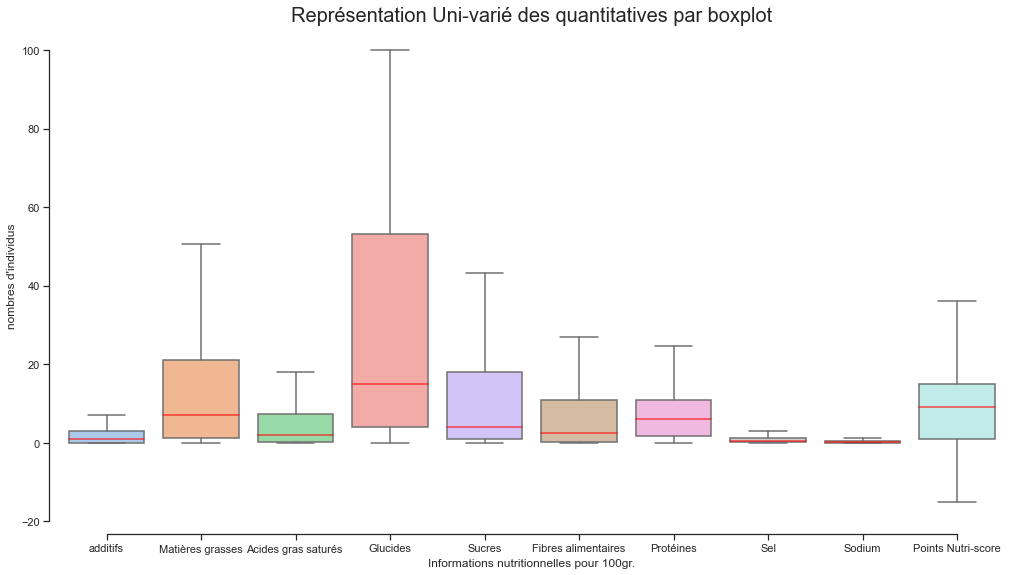

In [92]:
data_oqr = off_quantitative_replace.drop(columns=['code','energy_100g','ingredients_that_may_be_from_palm_oil_n','ingredients_from_palm_oil_n'])
label_x=["additifs","Matières grasses","Acides gras saturés ","Glucides","Sucres","Fibres alimentaires","Protéines","Sel","Sodium",'Points Nutri-score']
sns.set_theme(style="ticks", palette="pastel")

fig, ax = plt.subplots(figsize=(15, 6))
fig.canvas.manager.set_window_title('A Boxplot Quantitative uni-variate')
fig.subplots_adjust(left=0.075, right=0.95, top=1.9, bottom=.75)

# Initialize the figure with a logarithmic y axis
# ax.set_yscale("log")
ax.xaxis.grid(True, linestyle='-', which='major', color='lightgrey',
               alpha=0.5)
ax.set(xlabel="Informations nutritionnelles pour 100gr." , ylabel="nombres d'individus")
# ax.set_xscale(rt)
boxplot_num = sns.boxplot(data=data_oqr, medianprops=dict(color="red", alpha=0.7),showfliers=False)
# stripplot_num = sns.stripplot(data=data_oqr,jitter=0.0001,palette="Set2", size=4, marker="D",
#                    edgecolor="gray", alpha=.25, linewidth=1)
boxplot_num.set_title("Représentation Uni-varié des quantitatives par boxplot", fontsize=20)
boxplot_num.set_xticklabels(label_x, rotation=30, fontsize=10)
sns.despine(offset=10, trim=True)
off_quantitative_replace.describe()

In [93]:
# sns.set_theme(style="ticks", palette="pastel")
#
# fig, ax = plt.subplots(figsize=(15, 6))
# fig.canvas.manager.set_window_title('A Boxplot Quantitative uni-variate')
# fig.subplots_adjust(left=0.075, right=0.95, top=1.9, bottom=.75)
#
# # Initialize the figure with a logarithmic y axis
# # ax.set_yscale("log")
# ax.xaxis.grid(True, linestyle='-', which='major', color='lightgrey',
#                alpha=0.5)
# ax.set(xlabel="Informations nutritionnelles pour 100gr." , ylabel="nombres d'individus")
# stripplot_num = sns.stripplot(data=data,jitter=0.01,palette="Set2", size=20, marker="D", edgecolor="gray", alpha=.25, linewidth=1)
# stripplot_num.set_title("Représentation Uni-varié des quantitatives par stripplot", fontsize=20)
# stripplot_num.set_xticklabels(label_x, rotation=30, fontsize=10)
# sns.despine(offset=10, trim=True)

In [94]:
describe_by_columns(data_oqr)

|	columns name additives_n
|	columns dtype float64
----------------------------------------------------------------------
|	count		51361.0
|	mean		1.8637682288117443
|	50%			1.0
|	median		1.0
|	var			6.580330730080982
|	var(!biais)	6.580202610871269
|	std			2.5652155328706754	|
|	std(!biais)	2.5651905603426948
|	std(desc)	2.5652155328706754
|	25%			0.0
|	75%			3.0
|	min			0.0
|	max			31.0
|	skew		2.074031216556677
|	kurt		5.9531920363043085
|	columns name fat_100g
|	columns dtype float64
----------------------------------------------------------------------
|	count		45774.0
|	mean		13.400099184353182
|	50%			7.0
|	median		7.0
|	var			286.7403612070557
|	var(!biais)	286.7340969443474
|	std			16.93340961552208	|
|	std(!biais)	16.933224646958045
|	std(desc)	16.93340961552208
|	25%			1.3
|	75%			21.0
|	min			0.0
|	max			100.0
|	skew		2.2353136493585555
|	kurt		6.597114516807322
|	columns name saturated_fat_100g
|	columns dtype float64
-------------------------------------------------------

In [95]:
off_nutri = off_quantitative_replace[[
    'additives_n',
    'energy_100g',
    'fat_100g',
    'carbohydrates_100g',
    'fiber_100g',
    'proteins_100g',
    'salt_100g',
    'nutrition_score_fr_100g'
]].copy()
off_nutri.describe()

,additives_n,energy_100g,fat_100g,carbohydrates_100g,fiber_100g,proteins_100g,salt_100g,nutrition_score_fr_100g
count,51361.000000,6.257200e+04,45774.000000,45370.000000,60567.000000,62349.000000,60847.000000,59506.000000
mean,1.863768,1.172312e+03,13.400099,27.869274,15.587200,7.798353,1.288057,8.689712
std,2.565216,1.303762e+04,16.933410,27.375984,26.689183,8.008653,5.197795,9.035616
min,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,-15.000000
25%,0.000000,4.300000e+02,1.300000,4.100000,0.300000,1.800000,0.080000,1.000000
50%,1.000000,1.036000e+03,7.000000,14.900000,2.500000,6.000000,0.560000,9.000000
75%,3.000000,1.648000e+03,21.000000,53.200000,11.000000,11.000000,1.250000,15.000000
max,31.000000,3.251373e+06,100.000000,100.000000,100.000000,100.000000,100.000000,40.000000


In [96]:
off_nutri.isna().sum()

additives_n                38270
energy_100g                27059
fat_100g                   43857
carbohydrates_100g         44261
fiber_100g                 29064
proteins_100g              27282
salt_100g                  28784
nutrition_score_fr_100g    30125
dtype: int64

In [97]:
import scipy.stats as st

liste ={'fonctions':['var','skew','kurt']}
stat = pa.DataFrame(liste)
stat.join(off_nutri.apply(lambda x: [x.var(), x.skew(),x.kurtosis()]))

,fonctions,additives_n,energy_100g,fat_100g,carbohydrates_100g,fiber_100g,proteins_100g,salt_100g,nutrition_score_fr_100g
0,var,6.580331,1.699795e+08,286.740361,749.444484,712.312505,64.138526,27.017077,81.642364
1,skew,2.074031,2.476580e+02,2.235314,0.695250,1.757919,2.443203,13.677521,0.179837
2,kurt,5.953192,6.173040e+04,6.597115,-0.943085,1.610831,13.304228,216.087786,-0.940799


In [98]:
def nutri_score(x):

        if x > 18 : return 'e'
        elif x > 10 : return 'd'
        elif x > 2 : return 'c'
        elif x >= 0 : return 'b'
        else: return 'a'

In [99]:
off_nutri_score = off_nutri.join(off.nutrition_grade_fr).copy()
column_nutri_score = off_nutri_score.nutrition_score_fr_100g
# off_nutri_score.nutrition_grade_fr.fillna(off_nutri_score['nutrition-score-fr_100g'].apply(nutri_score),inplace=True)

In [100]:
off_nutri_score.nutrition_grade_fr.describe()

count     59506
unique        5
top           d
freq      16485
Name: nutrition_grade_fr, dtype: object

In [101]:
off_nutri_score.isna().sum()

additives_n                38270
energy_100g                27059
fat_100g                   43857
carbohydrates_100g         44261
fiber_100g                 29064
proteins_100g              27282
salt_100g                  28784
nutrition_score_fr_100g    30125
nutrition_grade_fr         30125
dtype: int64

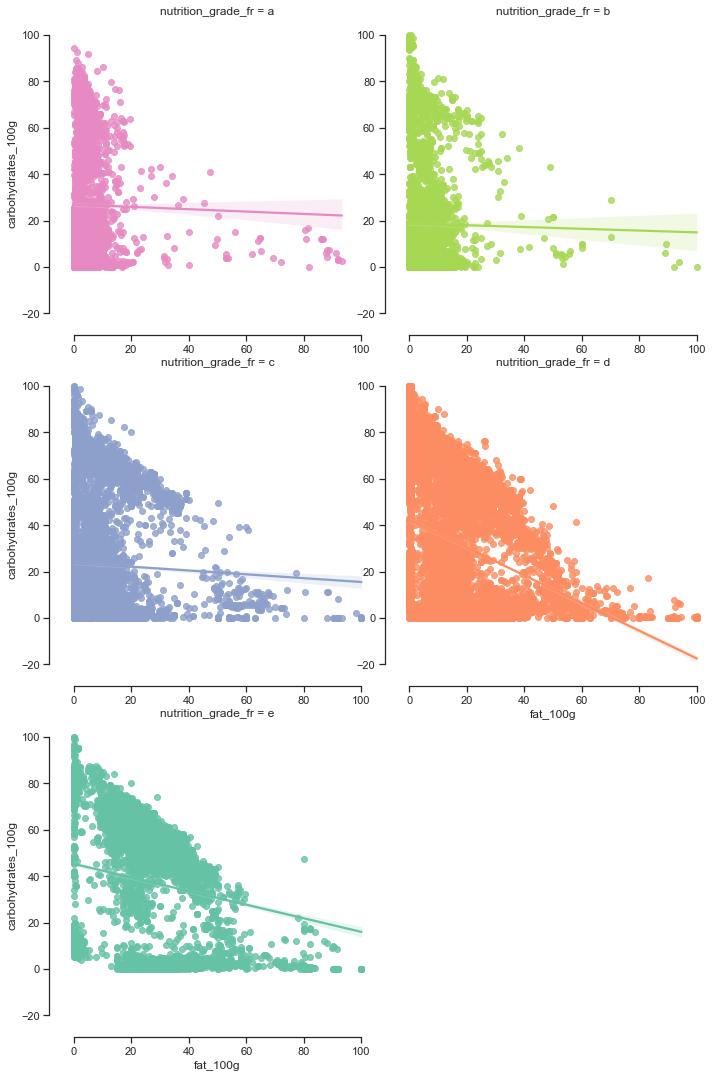

In [102]:
# scatterplot = sns.scatterplot(data=off_nutri, x="nutrition-score-fr_100g", y="additives_n",palette="Set1")
# scatterplot.fig.subplots_adjust(top=0.9)
# scatterplot.fig.suptitle(f"Analyse des variables quantitatives par régression linéaire", fontsize=25)
# scatterplot.set_xlabels("Score Nutrionel", fontsize=20)
# scatterplot.set_ylabels("nombres d'additfs", fontsize=20)
# plt.tight_layout()
# plt.show()

# columns_select = off_nutri.drop(columns=['energy_100g','additives_n','nutrition-score-fr_100g']).columns.values[1:]
# print(columns_select)
sns.set_theme(style="ticks", palette="pastel")

# fig, ax = plt.subplots(figsize=(15, 6))
# fig.canvas.manager.set_window_title('Analyse Quantitative multi-variate')
# fig.subplots_adjust(left=0.075, right=0.95, top=1.9, bottom=.75)
#
# ax.xaxis.grid(True, linestyle='-', which='major', color='lightgrey',alpha=0.5)
#
# ax.set(ylabel="Score nutritionnelles" , xlabel="nombres d'additifs")
stripplot_num = sns.lmplot(data=off_nutri_score,
                           x='fat_100g',
                           y='carbohydrates_100g',
                           col='nutrition_grade_fr',
                           col_order=['a','b','c','d','e'],
                           col_wrap=2,
                           hue='nutrition_grade_fr',
                           x_jitter=0.0001,
                           palette="Set2",
                           # height=10,
                           # marker="D",
                           # edgecolor="gray",
                           # alpha=.25,
                           # linewidth=1
                           )
# stripplot_num.fig.set_title("Représentation Multi-varié par stripplot", fontsize=20)
sns.despine(offset=10, trim=True)

In [103]:
s=off_nutri_score.nutrition_grade_fr
t=off_nutri_score.energy_100g
u=off_nutri_score.additives_n
v=off_nutri_score.fat_100g
w=off_nutri_score.carbohydrates_100g
x=off_nutri_score.fiber_100g
y=off_nutri_score.proteins_100g
z=off_nutri_score.salt_100g
x_c = (x - x.mean())
y_c = (y - y.mean())
x_cr = (x_c / x.std())
y_cr = (y_c / y.std())

In [104]:
from itertools import combinations,chain

t_df=pa.DataFrame(['v','w','x','y','z'])
t_c = t_df.apply(lambda c: list(combinations(c,2)))
# t=['v','w','x','y','z']
# combi = lambda c: list(combinations(c,2))
# t_c = list(map(lambda s: list(combinations(s,2)),t))

In [105]:
t_c_list = t_c.values.tolist()

In [106]:
t_l=['v','w','x','y','z']
def all_subsets(ss):
    return chain(*map(lambda x: combinations(ss, 2), range(0, 1)))

# for subset in list(all_subsets(t_l)):
#     print(f'{subset}')

pa_s = pa.Series(all_subsets(t_l))
# for value in s:
#     one, two = value
#     print(f"Value : {one} & {two}")
# for a,b in pa_s: print(f"Value : {a} & {b}")

In [107]:
tab_nutri = [t,u,v,w,x,y,z]
# tab_nutri[0]
serie_nutri = pa.Series(all_subsets(tab_nutri))

for a,b in serie_nutri:
    # print(f"Value : {a} & {b}")
    # print(f"Value : {a.where(a != np.nan).dropna()} & {b.where(b != np.nan).dropna()}")
    val1 = a.where(a != np.nan).dropna()
    val2 = b.where(b != np.nan).dropna()

    print(st.pearsonr(val1,val2)[0])

In [108]:
for a,b in serie_nutri:
    # print(f"Value : {a} & {b}")
    print(np.cov(a,b,ddof=0)[1,0])

nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan


In [109]:
x_c.describe()

count    6.056700e+04
mean     5.608402e-13
std      2.668918e+01
min     -1.558720e+01
25%     -1.528720e+01
50%     -1.308720e+01
75%     -4.587200e+00
max      8.441280e+01
Name: fiber_100g, dtype: float64

In [110]:
y_c.describe()

count    6.234900e+04
mean    -1.431140e-14
std      8.008653e+00
min     -7.798353e+00
25%     -5.998353e+00
50%     -1.798353e+00
75%      3.201647e+00
max      9.220165e+01
Name: proteins_100g, dtype: float64

In [111]:
y_col = ['fat_100g','carbohydrates_100g','fiber_100g','salt_100g']
x_col = ['saturated_fat_100g','sugars_100g','proteins_100g','sodium_100g']

In [112]:
data_nutri = data_oqr.drop(columns=['nutrition_score_fr_100g','additives_n']).copy()

<LOCAL_PATH>\AppData\Local\Temp/ipykernel_10148/2956358351.py:7: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
<LOCAL_PATH>"best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


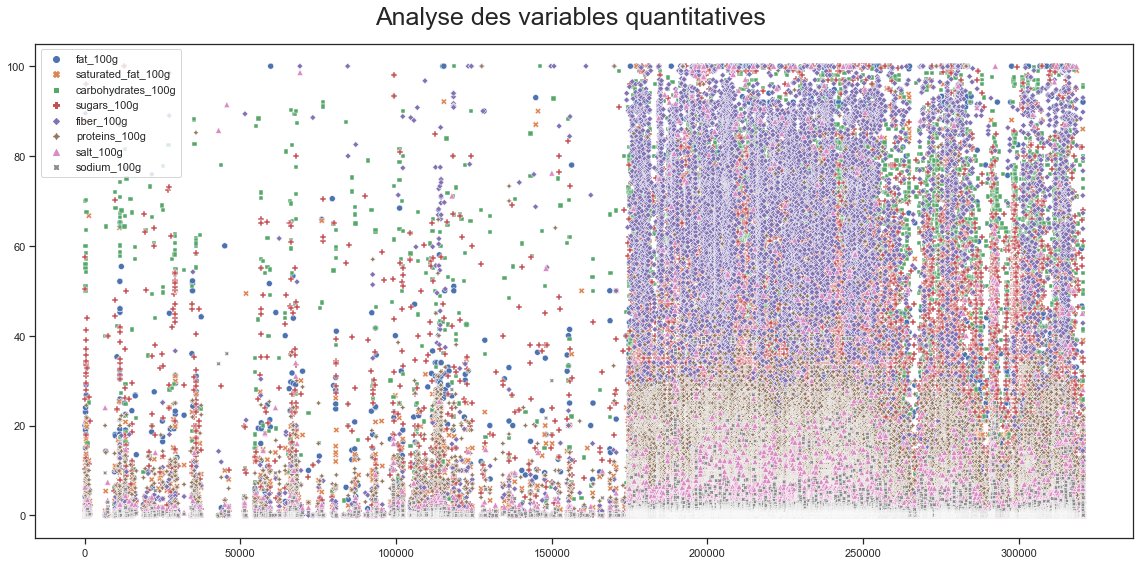

In [113]:
fig, ax = plt.subplots(figsize=(16,8))
# scatterplot = sns.scatterplot(data=off_nutri_score, x=x, y=y ,palette="Set1", hue='nutrition_grade_fr', hue_order=['a','b','c','d','e'])
# scatterplot = sns.scatterplot(data_nutri[x_col],data_nutri[y_col],palette="Set1", legend=label_x)
scatterplot = sns.scatterplot(data=data_nutri,palette="deep", legend=label_x)
fig.suptitle(f"Analyse des variables quantitatives", fontsize=25)
fig.subplots_adjust(top=0.9)
plt.tight_layout()
plt.show()

In [114]:
data_nutri = data_oqr.drop(columns=['nutrition_score_fr_100g','additives_n']).copy()
data_nutri

,fat_100g,saturated_fat_100g,carbohydrates_100g,sugars_100g,fiber_100g,proteins_100g,salt_100g,sodium_100g
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
46,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
48,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
106,20.0,12.5,70.0,57.5,2.5,2.5,0.09652,0.038
136,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...
320761,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
320763,0.2,0.2,0.5,0.5,0.2,0.5,0.02540,0.010
320764,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
320765,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


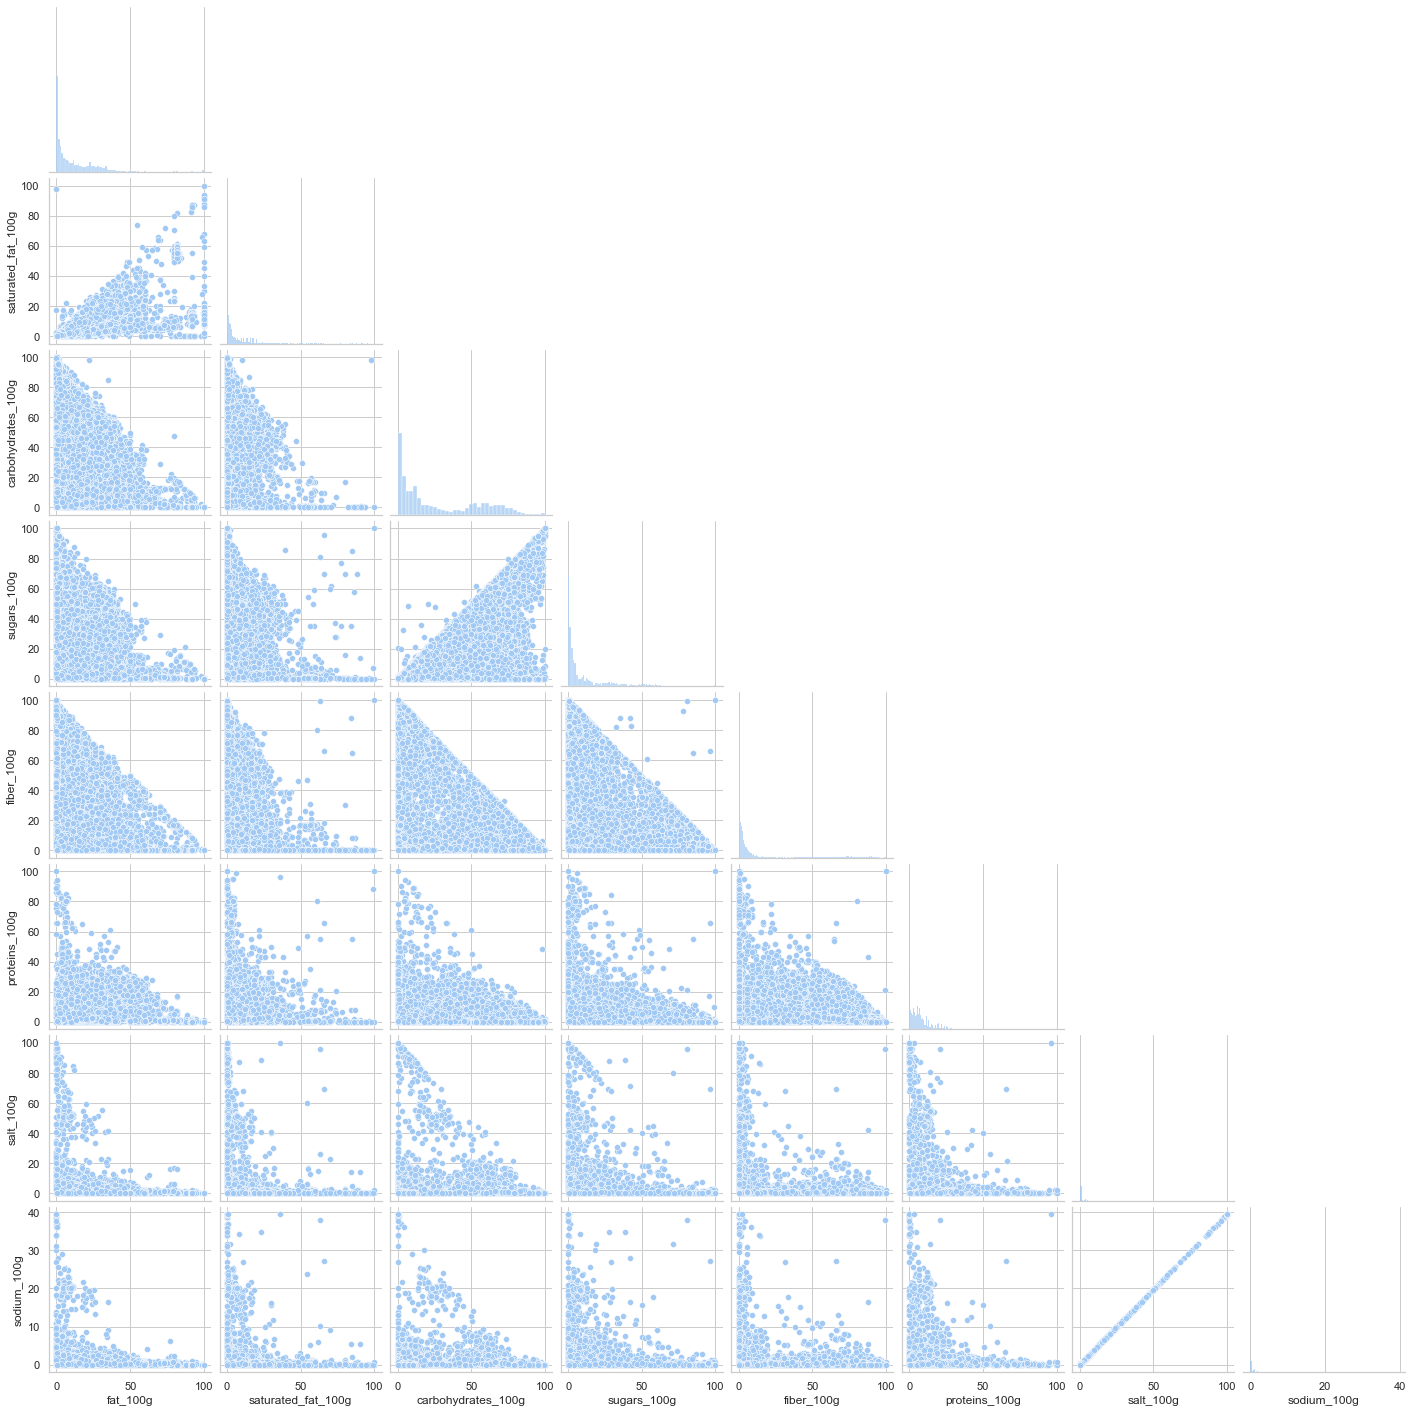

In [115]:
sns.set_theme(style="whitegrid", palette="pastel")
pairplot = sns.pairplot(data= data_nutri, corner=True)

In [116]:
data_nutri = data_oqr.drop(columns=['nutrition_score_fr_100g','additives_n']).copy()
data_nutri.isna().sum()

fat_100g              43857
saturated_fat_100g    29190
carbohydrates_100g    44261
sugars_100g           29062
fiber_100g            29064
proteins_100g         27282
salt_100g             28784
sodium_100g           29002
dtype: int64

In [117]:
cormat = data_nutri.corr()
cormat

,fat_100g,saturated_fat_100g,carbohydrates_100g,sugars_100g,fiber_100g,proteins_100g,salt_100g,sodium_100g
fat_100g,1.000000,0.730087,-0.076350,0.002169,-0.113045,0.130183,-0.015425,0.009058
saturated_fat_100g,0.730087,1.000000,-0.025744,0.079130,-0.054723,0.142194,-0.003355,0.008367
carbohydrates_100g,-0.076350,-0.025744,1.000000,0.635280,-0.346075,-0.129059,-0.073224,-0.085088
sugars_100g,0.002169,0.079130,0.635280,1.000000,-0.165358,-0.244264,-0.079128,-0.090548
fiber_100g,-0.113045,-0.054723,-0.346075,-0.165358,1.000000,0.055570,-0.017110,-0.005005
proteins_100g,0.130183,0.142194,-0.129059,-0.244264,0.055570,1.000000,0.060443,0.093984
salt_100g,-0.015425,-0.003355,-0.073224,-0.079128,-0.017110,0.060443,1.000000,1.000000
sodium_100g,0.009058,0.008367,-0.085088,-0.090548,-0.005005,0.093984,1.000000,1.000000


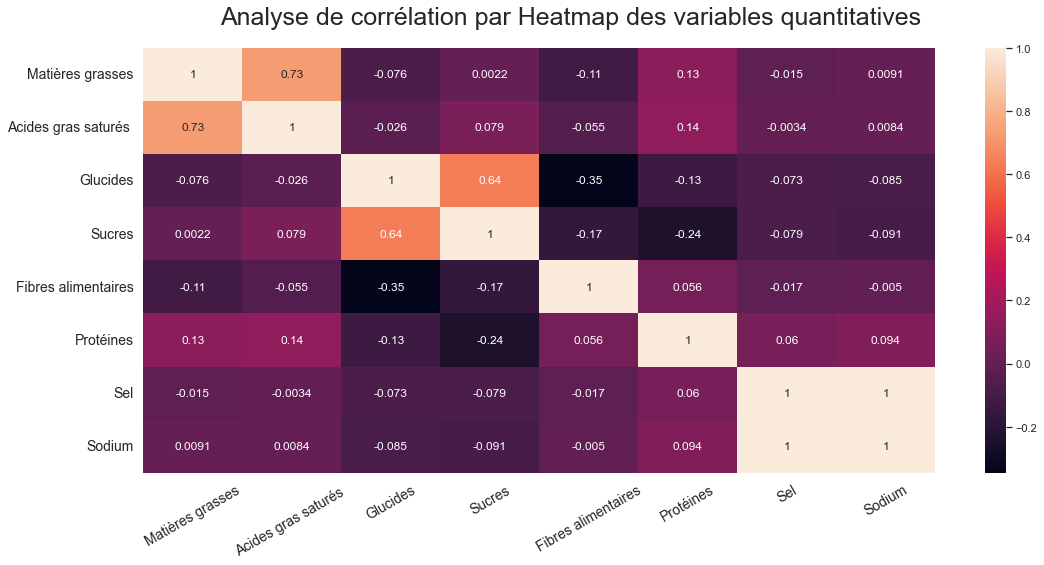

In [118]:
fig, ax = plt.subplots(figsize=(16,8))
heatmap = sns.heatmap(data= cormat, annot=True)

fig.suptitle(f"Analyse de corrélation par Heatmap des variables quantitatives", fontsize=25)
fig.subplots_adjust(top=0.9)
# ax.set_xticklabels(cormat.columns,rotation=45, fontsize=14)
heatmap.set_xticklabels(label_x[1:9], rotation=30, fontsize=14)
heatmap.set_yticklabels(label_x[1:9], fontsize=14)

plt.tight_layout()
plt.show()

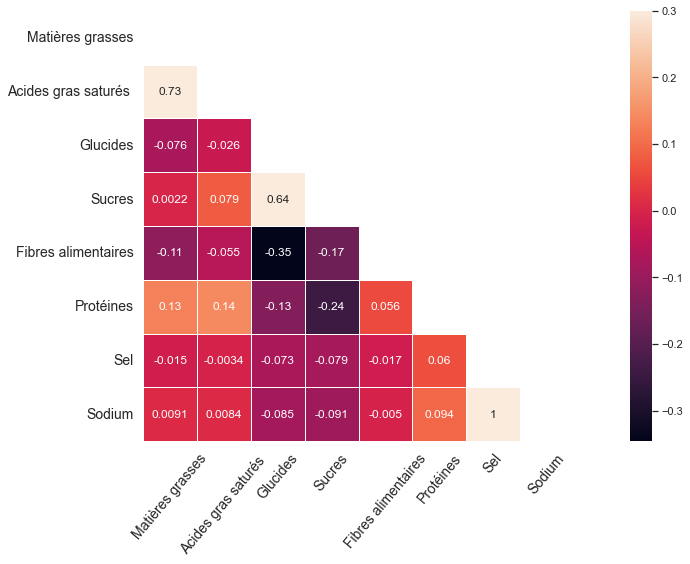

In [119]:
mask = np.zeros_like(cormat)
mask[np.triu_indices_from(mask)] = True
with sns.axes_style("white"):
    fig.suptitle(f"Analyse de corrélation par Heatmap des variables quantitatives", fontsize=25)
    fig.subplots_adjust(top=0.9)
    fig, ax = plt.subplots(figsize=(16, 8))
    ax = sns.heatmap(cormat, mask=mask, vmax=.3, square=True, linewidths=.5, annot=True)
    ax.set_xticklabels(label_x[1:9], rotation=50, fontsize=14)
    ax.set_yticklabels(label_x[1:9], fontsize=14)
    plt.tight_layout()
    plt.show()

In [120]:
# # lipide = pa.DataFrame(off_quantitative_replace.fat_100g).join(pa.DataFrame(off_quantitative_replace['saturated-fat_100g']))
# glucide = pa.DataFrame(off_quantitative_replace.carbohydrates_100g).join(pa.DataFrame(off_quantitative_replace.sugars_100g))
# # glucide = pa.concat([off_quantitative_replace.carbohydrates_100g,off_quantitative_replace.sugars_100g],axis=1).reset_index()
# # sel = pa.concat([off_quantitative_replace.salt_100g,off_quantitative_replace.sodium_100g],axis=1)
# imp_it = IterativeImputer()
# glucide_iit = imp_it.fit_transform(glucide)
# glucide.loc[glucide.index, :] = glucide_iit[:]
# temp = off_quantitative_replace.copy()
# sucre = temp.sugars_100g
# sucre.loc[sucre.index]=glucide[off_quantitative_replace.sugars_100g.name]
# temp

In [121]:
def value_groub_by(data_frame,column_name):
    taille_classe = 10 # taille des classes pour la discrétisation

    groupes = [] # va recevoir les données agrégées à afficher

    # on calcule des tranches allant de 0 au solde maximum par paliers de taille taille_classe
    tranches = np.arange(0, data_frame[column_name.name].max(), taille_classe)
    # print(tranches)
    tranches += int(taille_classe/2)# on décale les tranches d'une demi taille de classe
    # print(tranches)
    indices = np.digitize(data_frame[column_name.name], tranches) # associe chaque valeur à son numéro de classe
    # print(indices)
    for ind, tr in enumerate(tranches): # pour chaque tranche, ind reçoit le numéro de tranche et tr la tranche en question
        valeurs = data_frame.loc[indices==ind,column_name.name] # sélection des individus de la tranche ind
        if len(valeurs) > 0:
            g = {
                'valeurs': valeurs,
                'centre_classe': tr-(taille_classe/2),
                'taille': len(valeurs),
                'quartiles': [np.percentile(valeurs,p) for p in [25,50,75]]
            }
            groupes.append(g)
    return pa.DataFrame(groupes)

In [122]:
fat_decade = value_groub_by(off_quantitative_replace,off_quantitative_replace.fat_100g)
fat_decade

,valeurs,centre_classe,taille,quartiles
0,138 4.17 226 0.00 240 0.00 4...,0.0,20225,"[0.1, 1.0, 2.5]"
1,458 13.30 603 7.50 652 6.9...,10.0,9960,"[6.8, 8.9, 11.5]"
2,106 20.0 242 23.0 279 19.0 2...,20.0,6542,"[17.0, 20.0, 22.0]"
3,454 29.1 509 26.8 695 32.9 1...,30.0,5158,"[27.0, 29.0, 31.7]"
4,10375 35.3 34443 36.0 37424 44.2 6...,40.0,1759,"[36.0, 38.0, 40.0]"
5,11300 52.1 11303 52.1 11327 46.0 1...,50.0,740,"[47.0, 50.0, 52.0]"
6,11779 55.4 44991 60.0 113925 58.0 1...,60.0,383,"[56.1, 58.5, 60.0]"
7,11356 65.2 76148 65.9 79527 70.5 1...,70.0,197,"[69.8, 71.0, 72.3]"
8,156400 77.98476 175408 80.26340 178161 ...,80.0,354,"[80.0, 81.56372999999999, 82.0]"
9,128246 90.00 128253 90.00 144880 93.0...,90.0,185,"[91.0, 91.97, 92.0]"


In [123]:
off_quantitative_replace

,code,additives_n,ingredients_from_palm_oil_n,ingredients_that_may_be_from_palm_oil_n,energy_100g,fat_100g,saturated_fat_100g,carbohydrates_100g,sugars_100g,fiber_100g,proteins_100g,salt_100g,sodium_100g,nutrition_score_fr_100g
0,3087,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
46,24600,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
48,27205,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
106,36252,1.0,0.0,0.0,1883.0,20.0,12.5,70.0,57.5,2.5,2.5,0.09652,0.038,22.0
136,39259,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
320761,9906410000009,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
320763,99111250,0.0,0.0,0.0,21.0,0.2,0.2,0.5,0.5,0.2,0.5,0.02540,0.010,2.0
320764,9918,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
320765,9935010000003,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [124]:
my_column = ['fat_100g','saturated_fat_100g']
fat = off_quantitative_replace[my_column].copy()
fat.value_counts()

fat_100g  saturated_fat_100g
0.0       0.0                   3370
0.5       0.1                    760
0.1       0.0                    727
          0.1                    515
0.2       0.0                    446
                                ... 
17.2      11.1                     1
          10.7                     1
          9.3                      1
4.2       3.5                      1
16.1      8.3                      1
Length: 12753, dtype: int64

In [125]:
fat.loc[fat.saturated_fat_100g > 60.0]

,fat_100g,saturated_fat_100g
1355,NaN,66.7
11179,NaN,64.0
76149,NaN,65.6
115370,100.0,92.1
144879,NaN,87.0
...,...,...
314813,NaN,86.7
315860,100.0,86.0
316993,NaN,94.0
318627,NaN,99.0


In [126]:
fat.describe()

,fat_100g,saturated_fat_100g
count,45774.000000,60441.000000
mean,13.400099,5.430233
std,16.933410,8.495122
min,0.000000,0.000000
25%,1.300000,0.300000
50%,7.000000,2.000000
75%,21.000000,7.400000
max,100.000000,100.000000


In [127]:
fat_score= fat.join(off_drop_ref.nutrition_grade_fr.dropna())
fat_score.isna().sum()

fat_100g              43857
saturated_fat_100g    29190
nutrition_grade_fr    30125
dtype: int64

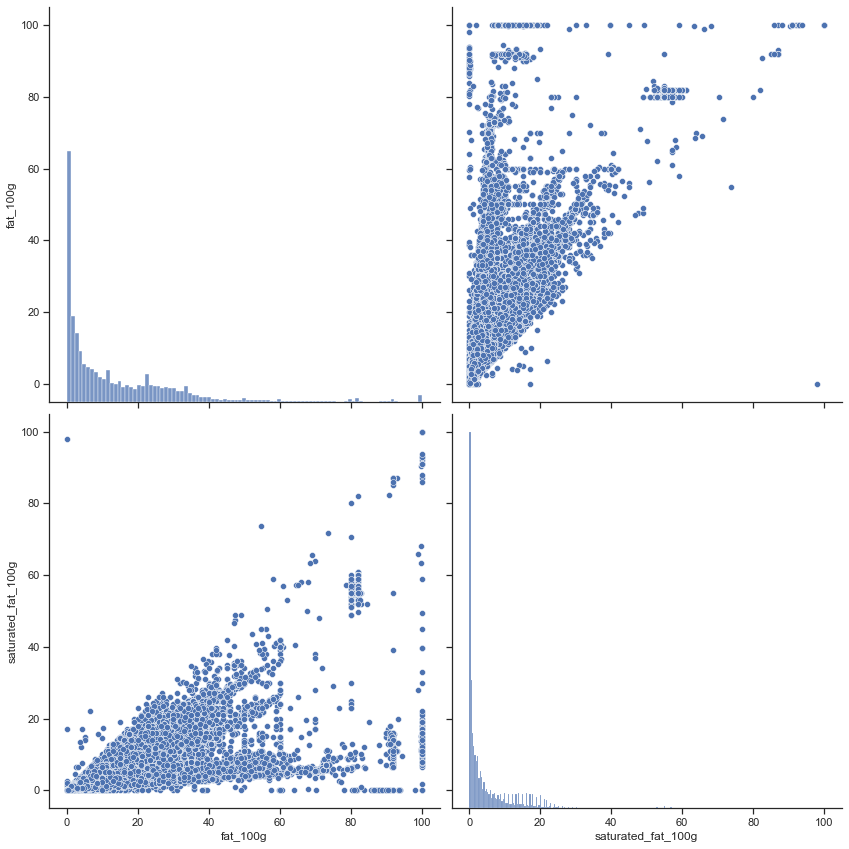

In [128]:
sns.set_theme(style="ticks")
sns.pairplot(fat_score, height = 6)

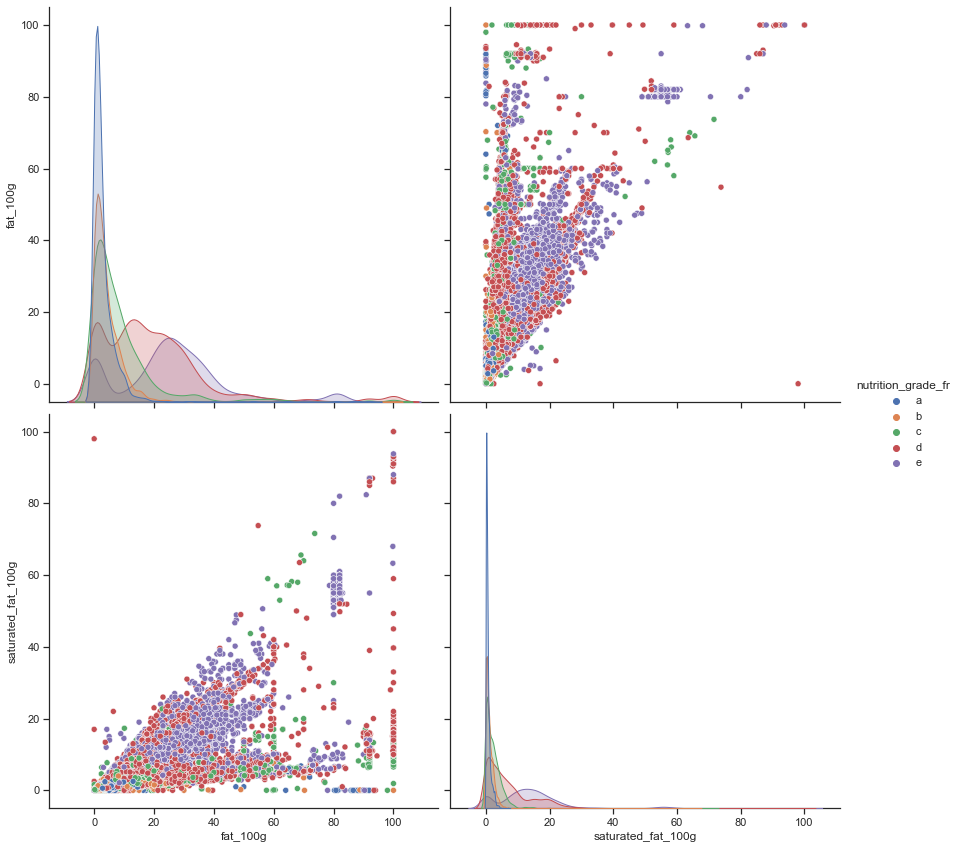

In [129]:
sns.set_theme(style="ticks")
sns.pairplot(fat_score, hue='nutrition_grade_fr', hue_order=['a','b','c','d','e'], height = 6)

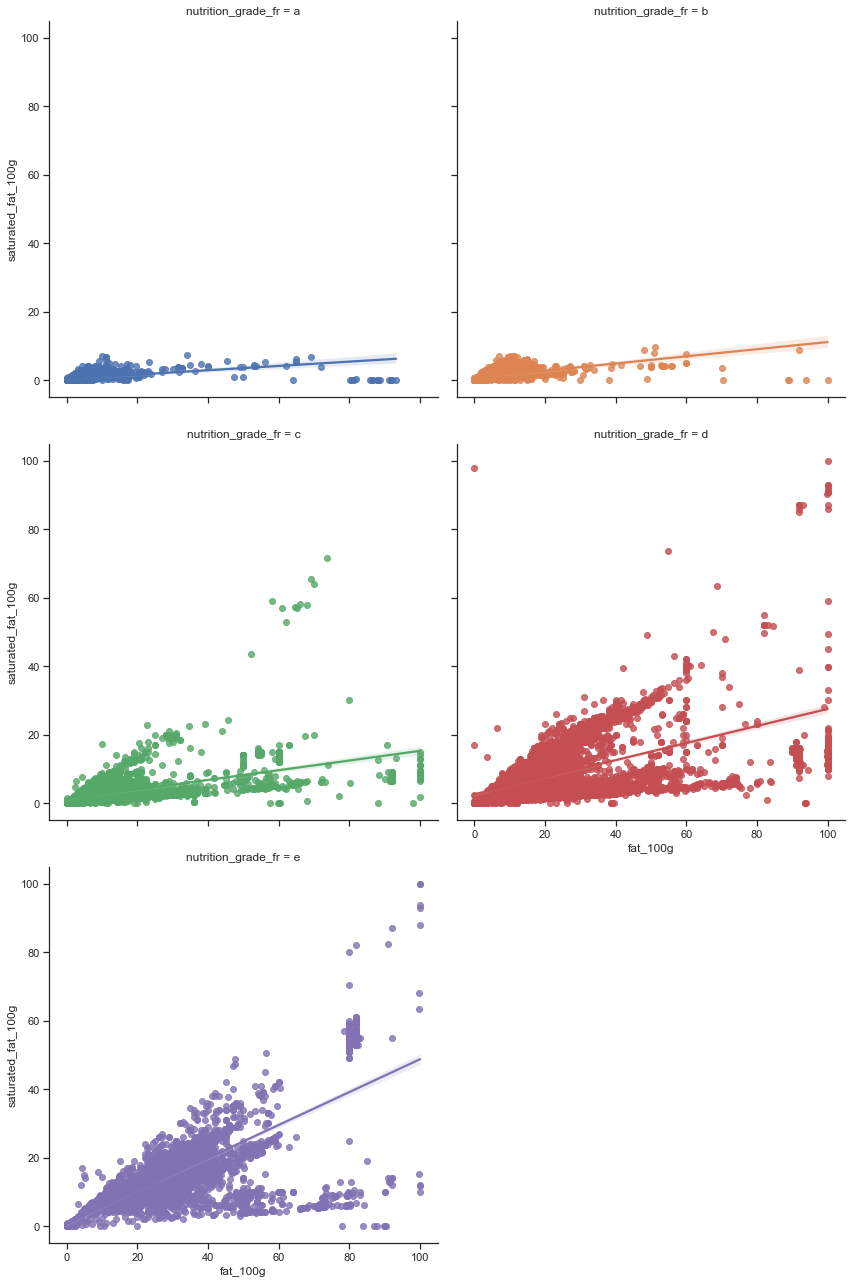

In [130]:
sns.set_theme(style="ticks")
# sns.lmplot(data=fat_score, hue='nutrition_grade_fr', hue_order=['a','b','c','d','e'], height = 8)
sns.lmplot(data=fat_score, x='fat_100g', y='saturated_fat_100g',col="nutrition_grade_fr",col_order=['a','b','c','d','e'], col_wrap=2, hue='nutrition_grade_fr', hue_order=['a','b','c','d','e'], height = 6)

In [131]:
from scipy.stats import linregress
import statsmodels.api as sm
def fit_line2(x, y):
    """Return slope, intercept of best fit line."""
    X = sm.add_constant(x)
    model = sm.OLS(y, X, missing='drop') # ignores entires where x or y is NaN
    fit = model.fit()
    return fit.params[1], fit.params[0]

In [132]:
fat_score.loc[fat_score.nutrition_grade_fr=='a'].mean()

<LOCAL_PATH>\AppData\Local\Temp/ipykernel_10148/115531071.py:1: FutureWarning: Dropping of nuisance columns in DataFrame reductions (with 'numeric_only=None') is deprecated; in a future version this will raise TypeError.  Select only valid columns before calling the reduction.
  fat_score.loc[fat_score.nutrition_grade_fr=='a'].mean()


fat_100g              3.020609
saturated_fat_100g    0.600743
dtype: float64

In [133]:
fat_score_full = fat_score.loc[(~fat_score.nutrition_grade_fr.isna() & ~fat_score.saturated_fat_100g.isna())]
fat_score_a = fat_score_full.loc[fat_score.nutrition_grade_fr=='a' ]
fat_score_a_dr = fat_score_a.dropna()
fat_score_a_dr
fat_score_full.isna().sum()

fat_100g              17008
saturated_fat_100g        0
nutrition_grade_fr        0
dtype: int64

In [134]:
# def imput_lineare(y,a,b):
#     x = (y - b)/a
#     if x > 100 :
#         return 100
#     elif x < b :
#         return 0
#     else :return x

In [135]:
# nutri_val = fat_score.nutrition_grade_fr.dropna().unique()
# fat_score_full_copy = fat_score_full.copy()
# # long = 0
# # lon = 0
# for n in nutri_val:
#     fat_score_select = fat_score_full.loc[fat_score.nutrition_grade_fr==n]
#     fat_score_select_dr = fat_score_select.dropna()
#     # long = long + len(fat_score_select)
#     # print(f"nutri score {n} taille df :{fat_score_select.shape} long {long}")
#     x = fat_score_select_dr.fat_100g
#     y = fat_score_select_dr.saturated_fat_100g
#     a, b, r, p_value, std_err = linregress(x, y)
#     # print(f"a   ={a:8.3f}\nb   ={b:8.3f}\nr^2 ={r**2:8.5f}")
#     fat_score_full_copy.fat_100g.fillna(fat_score_select.saturated_fat_100g.apply(imput_lineare,a=a,b=b),inplace=True)


In [136]:
my_column = ['fat_100g','saturated_fat_100g']
fat_score[my_column].describe()

,fat_100g,saturated_fat_100g
count,45774.000000,60441.000000
mean,13.400099,5.430233
std,16.933410,8.495122
min,0.000000,0.000000
25%,1.300000,0.300000
50%,7.000000,2.000000
75%,21.000000,7.400000
max,100.000000,100.000000


In [137]:
# fat_score_full_copy.describe()

In [138]:
# off_quantitative_replace_fat = off_quantitative_replace.copy()
# off_quantitative_replace_fat.loc[fat_score_full_copy.index, 'fat_100g'] = fat_score_full_copy.fat_100g[:]
# off_quantitative_replace_fat.fillna(fat_score_full_copy.iloc[:], inplace=True)

In [139]:
# off_quantitative_replace_fat.describe()

In [140]:
# off_quantitative_replace_fat.shape

In [189]:
def linear_regression(y,a,b):
    x = (y - b)/a
    if x > 100 :
        return 100
    elif x < b :
        return 0
    else :return x

In [190]:
my_column = ['fat_100g','saturated_fat_100g']
fat = off_quantitative_replace[my_column].copy()
fat_score= fat.join(off_drop_ref.nutrition_grade_fr.dropna())
nutri_val = fat_score.nutrition_grade_fr.dropna().unique()
fat_score_full_copy = fat_score_full.copy()
for n in nutri_val:
    fat_score_select = fat_score_full.loc[fat_score.nutrition_grade_fr==n]
    fat_score_select_dr = fat_score_select.dropna()
    x = fat_score_select_dr.fat_100g
    y = fat_score_select_dr.saturated_fat_100g
    slo, inter, r_val, p_value, std_err = linregress(x, y)
    fat_score_full_copy.fat_100g.fillna(fat_score_select.saturated_fat_100g.apply(linear_regression,a=slo,b=inter),inplace=True)
off_quantitative_replace_fat = off_quantitative_replace.copy()
off_quantitative_replace_fat.loc[fat_score_full_copy.index, 'fat_100g'] = fat_score_full_copy.fat_100g[:]
off_quantitative_replace_fat.fillna(fat_score_full_copy.iloc[:], inplace=True)

In [195]:
off_quantitative_replace_fat.describe()

,additives_n,ingredients_from_palm_oil_n,ingredients_that_may_be_from_palm_oil_n,energy_100g,fat_100g,saturated_fat_100g,carbohydrates_100g,sugars_100g,fiber_100g,proteins_100g,salt_100g,sodium_100g,nutrition_score_fr_100g
count,51361.000000,51361.000000,51361.000000,6.257200e+04,62782.000000,60441.000000,45370.000000,60569.000000,60567.000000,62349.000000,60847.000000,60629.000000,59506.000000
mean,1.863768,0.070073,0.149257,1.172312e+03,13.689037,5.430233,27.869274,13.434833,15.587200,7.798353,1.288057,0.453346,8.689712
std,2.565216,0.258982,0.452662,1.303762e+04,18.043199,8.495122,27.375984,19.058269,26.689183,8.008653,5.197795,1.636727,9.035616
min,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,-0.100000,0.000000,0.000000,0.000000,0.000000,-15.000000
25%,0.000000,0.000000,0.000000,4.300000e+02,0.500000,0.300000,4.100000,1.000000,0.300000,1.800000,0.080000,0.031496,1.000000
50%,1.000000,0.000000,0.000000,1.036000e+03,6.600000,2.000000,14.900000,4.100000,2.500000,6.000000,0.560000,0.220000,9.000000
75%,3.000000,0.000000,0.000000,1.648000e+03,21.600000,7.400000,53.200000,17.900000,11.000000,11.000000,1.250000,0.490000,15.000000
max,31.000000,2.000000,5.000000,3.251373e+06,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,39.370079,40.000000


In [191]:
def linear_regression_imputation(data_mv,col_imput, col_ref):
    # pour réaliser notre imputation affine on doit selectionne les colonnes pour effectuer un groupages des individus
    # boucle sur les valeurs de sous groupe
    nutri_val = data_mv.nutrition_grade_fr.dropna().unique()
    for n in nutri_val:
        data_frame_subgroup = data_mv.loc[data_mv.nutrition_grade_fr==n] # dataframe divise en sous groupe pour une imputation plus affine
        data_frame_ref = data_frame_subgroup.dropna() # datafrane de reference sans valeur manquante
        x = data_frame_ref[col_imput] # doit recevoir la colonne a impute d'un dataframe sans valeur manquante comme reference pour le calcule dans la fonction linregress()
        y = data_frame_ref[col_ref] # doit recevoir la colonne a de support d'un dataframe sans valeur manquante comme reference pour le calcule dans la fonction linregress()
        slop, interc, r_val, p_value, std_err = linregress(x, y)
        # on remplace les valeurs manquantes par la fonction qui retourne la valeur calculée issu de la droite de régression linaire
        data_mv[col_imput].fillna(data_frame_subgroup[col_ref].apply(linear_regression,a=slop,b=interc),inplace=True)
    return data_mv


In [193]:
test_data = off_quantitative_replace.join(off_drop_ref.nutrition_grade_fr.dropna()).copy()
test_fonction= linear_regression_imputation(test_data,'fat_100g','saturated_fat_100g')
test_fonction.describe()

,additives_n,ingredients_from_palm_oil_n,ingredients_that_may_be_from_palm_oil_n,energy_100g,fat_100g,saturated_fat_100g,carbohydrates_100g,sugars_100g,fiber_100g,proteins_100g,salt_100g,sodium_100g,nutrition_score_fr_100g
count,51361.000000,51361.000000,51361.000000,6.257200e+04,62782.000000,60441.000000,45370.000000,60569.000000,60567.000000,62349.000000,60847.000000,60629.000000,59506.000000
mean,1.863768,0.070073,0.149257,1.172312e+03,13.661862,5.430233,27.869274,13.434833,15.587200,7.798353,1.288057,0.453346,8.689712
std,2.565216,0.258982,0.452662,1.303762e+04,18.002510,8.495122,27.375984,19.058269,26.689183,8.008653,5.197795,1.636727,9.035616
min,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,-0.100000,0.000000,0.000000,0.000000,0.000000,-15.000000
25%,0.000000,0.000000,0.000000,4.300000e+02,0.500000,0.300000,4.100000,1.000000,0.300000,1.800000,0.080000,0.031496,1.000000
50%,1.000000,0.000000,0.000000,1.036000e+03,6.500000,2.000000,14.900000,4.100000,2.500000,6.000000,0.560000,0.220000,9.000000
75%,3.000000,0.000000,0.000000,1.648000e+03,21.481691,7.400000,53.200000,17.900000,11.000000,11.000000,1.250000,0.490000,15.000000
max,31.000000,2.000000,5.000000,3.251373e+06,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,39.370079,40.000000


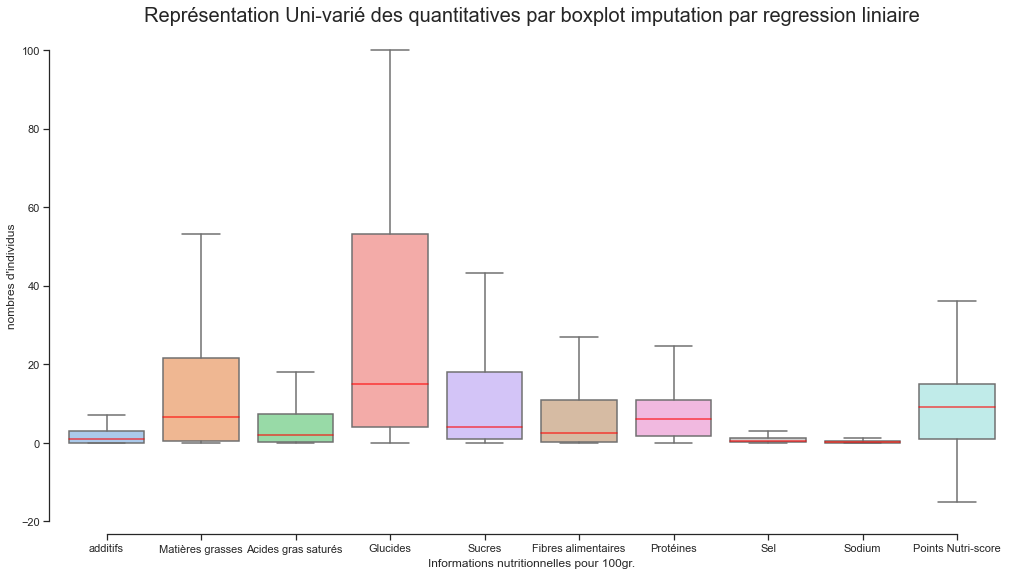

In [145]:
data_oqrf = off_quantitative_replace_fat.drop(columns=['code','energy_100g','ingredients_that_may_be_from_palm_oil_n','ingredients_from_palm_oil_n'])
label_x=["additifs","Matières grasses","Acides gras saturés ","Glucides","Sucres","Fibres alimentaires","Protéines","Sel","Sodium",'Points Nutri-score']
sns.set_theme(style="ticks", palette="pastel")

fig, ax = plt.subplots(figsize=(15, 6))
fig.canvas.manager.set_window_title('A Boxplot Quantitative uni-variate')
fig.subplots_adjust(left=0.075, right=0.95, top=1.9, bottom=.75)

# Initialize the figure with a logarithmic y axis
# ax.set_yscale("log")
ax.xaxis.grid(True, linestyle='-', which='major', color='lightgrey',
               alpha=0.5)
ax.set(xlabel="Informations nutritionnelles pour 100gr." , ylabel="nombres d'individus")
# ax.set_xscale(rt)
boxplot_num = sns.boxplot(data=data_oqrf, medianprops=dict(color="red", alpha=0.7),showfliers=False)
# stripplot_num = sns.stripplot(data=data_oqrf,jitter=0.0001,palette="Set2", size=4, marker="D",
#                    edgecolor="gray", alpha=.25, linewidth=1)
boxplot_num.set_title("Représentation Uni-varié des quantitatives par boxplot imputation par regression liniaire", fontsize=20)
boxplot_num.set_xticklabels(label_x, rotation=30, fontsize=10)
sns.despine(offset=10, trim=True)

In [146]:
# fat_score_full_test = fat_score.loc[(~fat_score.nutrition_grade_fr.isna() & ~fat_score.saturated_fat_100g.isna())]
# fat_score_full_test.isna().sum()

In [147]:
# fat_score_a = fat_score_full_test.loc[fat_score.nutrition_grade_fr=='b' ]
# fat_score_a_dr = fat_score_a.dropna()
# fat_score_a.isna().sum()

In [148]:
# x = fat_score_a_dr.fat_100g
# y = fat_score_a_dr.saturated_fat_100g
# a, b, r, p_value, std_err = linregress(x, y)
# fat_score_a.fat_100g.fillna(fat_score_a.saturated_fat_100g.apply(imput_lineare,a=a,b=b),inplace=True)
# fat_score_a.loc[fat_score.nutrition_grade_fr=='b'].isna().sum()

In [149]:
# fat_score_a = fat_score.loc[fat_score.nutrition_grade_fr=='a']

In [150]:
x = fat_score_a.fat_100g
y = fat_score_a.saturated_fat_100g
fit_line2(x,y)

(0.06291483119089081, 0.3815250604609821)

In [151]:
fat_score_a_dr = fat_score_a.dropna()
x = fat_score_a_dr.fat_100g
y = fat_score_a_dr.saturated_fat_100g
parametres = np.polyfit(x, y, 1)
print(parametres)

[0.06291483 0.38152506]


In [152]:
a, b, r, p_value, std_err = linregress(x, y)
print("a   ={:8.3f}\nb   ={:8.3f}\nr^2 ={:8.5f}".format(a, b, r**2))

a   =   0.063
b   =   0.382
r^2 = 0.24876


In [153]:
# fx= a * x + b
x2 = y.apply(lambda y: (y - b)/a if y >= b else 0)
x2.mean()

5.1723162567581475

In [154]:
fat_score_a_dr.describe()

,fat_100g,saturated_fat_100g
count,7468.000000,7468.000000
mean,3.020609,0.571566
std,5.836596,0.736249
min,0.000000,0.000000
25%,0.500000,0.100000
50%,1.600000,0.300000
75%,3.600000,0.700000
max,93.200000,7.300000


In [155]:
fat_score_a_dr

,fat_100g,saturated_fat_100g,nutrition_grade_fr
680,1.60,0.60,a
894,4.40,2.00,a
1356,5.30,1.90,a
11810,4.46,0.89,a
12967,0.50,0.10,a
...,...,...,...
319578,0.00,0.00,a
320249,0.00,0.00,a
320494,0.00,0.00,a
320497,0.00,0.00,a


(7468, 1) (7468, 1)
(7468,) (7468,)


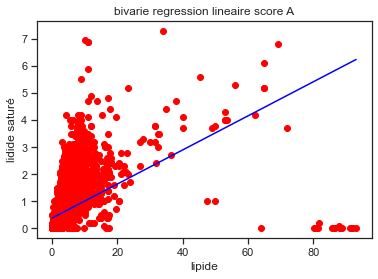

In [156]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures

x = fat_score_a_dr.iloc[:, 0:1].values
y = fat_score_a_dr.iloc[:, 1].values
x1 = fat_score_a_dr.drop(columns=['saturated_fat_100g','nutrition_grade_fr']).values
y1 = fat_score_a_dr.saturated_fat_100g.values
print(x.shape,x1.shape)
print(y.shape,y1.shape)

linreg = LinearRegression()
linreg.fit(x1, y1)
polreg = PolynomialFeatures(degree=1)
x_poly = polreg.fit_transform(x)
linreg2 = LinearRegression()
linreg2.fit(x_poly, y)
x_grid = np.arange(min(x), max(x), 0.1)
x_grid = x_grid.reshape((len(x_grid), 1))
plt.scatter(x, y, color = "red")
plt.plot(x_grid, linreg2.predict(polreg.fit_transform(x_grid)), color = "blue" )
plt.title("bivarie regression lineaire score A")
plt.ylabel("lidide saturé")
plt.xlabel("lipide")
plt.show()

In [157]:
polreg = PolynomialFeatures(degree=1)
x_poly = polreg.fit_transform(x)
linreg2 = LinearRegression()
linreg2.fit(x_poly, y)

LinearRegression()

In [158]:
# fat_score_a.fat_100g.fillna(fat_score_a.saturated_fat_100g.apply(imput_lineare,a=a,b=b)).describe()

In [159]:
def replace_imput_iter(x,column_ref,column_nan):
    df = pa.DataFrame(column_ref).join(column_nan)
    df.loc[df.index,:] = IterativeImputer().fit_transform(df)[:]
    column_nan.loc[column_nan.index]=df[column_nan.name]
    return x

In [160]:
# replace_nan_to_iter = off_quantitative_replace[['fat_100g','saturated-fat_100g','carbohydrates_100g','sugars_100g','salt_100g','sodium_100g']].copy()
off_quantitative_iter = off_quantitative_replace.copy()
off_quantitative_iter.apply(replace_imput_iter,column_ref=off_quantitative_iter.carbohydrates_100g,column_nan=off_quantitative_iter.sugars_100g)
off_quantitative_iter.apply(replace_imput_iter,column_ref=off_quantitative_iter.fat_100g,column_nan=off_quantitative_iter.saturated_fat_100g)
off_quantitative_iter.apply(replace_imput_iter,column_ref=off_quantitative_iter.salt_100g,column_nan=off_quantitative_iter.sodium_100g)
off_quantitative_iter.apply(replace_imput_iter,column_ref=off_quantitative_iter.sugars_100g ,column_nan=off_quantitative_iter.carbohydrates_100g)
off_quantitative_iter.apply(replace_imput_iter,column_ref=off_quantitative_iter.saturated_fat_100g ,column_nan=off_quantitative_iter.fat_100g)
off_quantitative_iter.apply(replace_imput_iter,column_ref=off_quantitative_iter.sodium_100g ,column_nan=off_quantitative_iter.salt_100g)

,code,additives_n,ingredients_from_palm_oil_n,ingredients_that_may_be_from_palm_oil_n,energy_100g,fat_100g,saturated_fat_100g,carbohydrates_100g,sugars_100g,fiber_100g,proteins_100g,salt_100g,sodium_100g,nutrition_score_fr_100g
0,3087,NaN,NaN,NaN,NaN,13.564228,5.426429,28.455312,13.385502,NaN,NaN,1.288057,0.507109,NaN
46,24600,NaN,NaN,NaN,NaN,13.564228,5.426429,28.455312,13.385502,NaN,NaN,1.288057,0.507109,NaN
48,27205,NaN,NaN,NaN,NaN,13.564228,5.426429,28.455312,13.385502,NaN,NaN,1.288057,0.507109,NaN
106,36252,1.0,0.0,0.0,1883.0,20.000000,12.500000,70.000000,57.500000,2.5,2.5,0.096520,0.038000,22.0
136,39259,NaN,NaN,NaN,NaN,13.564228,5.426429,28.455312,13.385502,NaN,NaN,1.288057,0.507109,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
320761,9906410000009,NaN,NaN,NaN,NaN,13.564228,5.426429,28.455312,13.385502,NaN,NaN,1.288057,0.507109,NaN
320763,99111250,0.0,0.0,0.0,21.0,0.200000,0.200000,0.500000,0.500000,0.2,0.5,0.025400,0.010000,2.0
320764,9918,NaN,NaN,NaN,NaN,13.564228,5.426429,28.455312,13.385502,NaN,NaN,1.288057,0.507109,NaN
320765,9935010000003,0.0,0.0,0.0,NaN,13.564228,5.426429,28.455312,13.385502,NaN,NaN,1.288057,0.507109,NaN


In [161]:
off_quantitative_replace_fat.describe()

,additives_n,ingredients_from_palm_oil_n,ingredients_that_may_be_from_palm_oil_n,energy_100g,fat_100g,saturated_fat_100g,carbohydrates_100g,sugars_100g,fiber_100g,proteins_100g,salt_100g,sodium_100g,nutrition_score_fr_100g
count,51361.000000,51361.000000,51361.000000,6.257200e+04,62782.000000,60441.000000,45370.000000,60569.000000,60567.000000,62349.000000,60847.000000,60629.000000,59506.000000
mean,1.863768,0.070073,0.149257,1.172312e+03,13.689037,5.430233,27.869274,13.434833,15.587200,7.798353,1.288057,0.453346,8.689712
std,2.565216,0.258982,0.452662,1.303762e+04,18.043199,8.495122,27.375984,19.058269,26.689183,8.008653,5.197795,1.636727,9.035616
min,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,-0.100000,0.000000,0.000000,0.000000,0.000000,-15.000000
25%,0.000000,0.000000,0.000000,4.300000e+02,0.500000,0.300000,4.100000,1.000000,0.300000,1.800000,0.080000,0.031496,1.000000
50%,1.000000,0.000000,0.000000,1.036000e+03,6.600000,2.000000,14.900000,4.100000,2.500000,6.000000,0.560000,0.220000,9.000000
75%,3.000000,0.000000,0.000000,1.648000e+03,21.600000,7.400000,53.200000,17.900000,11.000000,11.000000,1.250000,0.490000,15.000000
max,31.000000,2.000000,5.000000,3.251373e+06,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,39.370079,40.000000


In [162]:
off_quantitative_iter.describe()

,additives_n,ingredients_from_palm_oil_n,ingredients_that_may_be_from_palm_oil_n,energy_100g,fat_100g,saturated_fat_100g,carbohydrates_100g,sugars_100g,fiber_100g,proteins_100g,salt_100g,sodium_100g,nutrition_score_fr_100g
count,51361.000000,51361.000000,51361.000000,6.257200e+04,89631.000000,89631.000000,89631.000000,89631.000000,60567.000000,62349.000000,89631.000000,89631.000000,59506.000000
mean,1.863768,0.070073,0.149257,1.172312e+03,13.564228,5.426429,28.455312,13.385502,15.587200,7.798353,1.288057,0.507109,8.689712
std,2.565216,0.258982,0.452662,1.303762e+04,13.790487,7.080572,21.393257,15.837027,26.689183,8.008653,4.282610,1.686072,9.035616
min,0.000000,0.000000,0.000000,0.000000e+00,0.000000,-0.213236,0.000000,-1.808813,0.000000,0.000000,0.000000,-0.000001,-15.000000
25%,0.000000,0.000000,0.000000,4.300000e+02,5.005792,0.800000,14.300000,2.100000,0.300000,1.800000,0.170000,0.066929,1.000000
50%,1.000000,0.000000,0.000000,1.036000e+03,13.564228,5.426429,28.455312,13.385502,2.500000,6.000000,1.200000,0.472441,9.000000
75%,3.000000,0.000000,0.000000,1.648000e+03,13.564228,5.426429,29.200000,13.385502,11.000000,11.000000,1.288057,0.507109,15.000000
max,31.000000,2.000000,5.000000,3.251373e+06,162.723418,100.000000,112.849648,100.000000,100.000000,100.000000,100.000000,39.370203,40.000000


In [163]:
off_quantitative_iter.isna().sum()

code                                           0
additives_n                                38270
ingredients_from_palm_oil_n                38270
ingredients_that_may_be_from_palm_oil_n    38270
energy_100g                                27059
fat_100g                                       0
saturated_fat_100g                             0
carbohydrates_100g                             0
sugars_100g                                    0
fiber_100g                                 29064
proteins_100g                              27282
salt_100g                                      0
sodium_100g                                    0
nutrition_score_fr_100g                    30125
dtype: int64

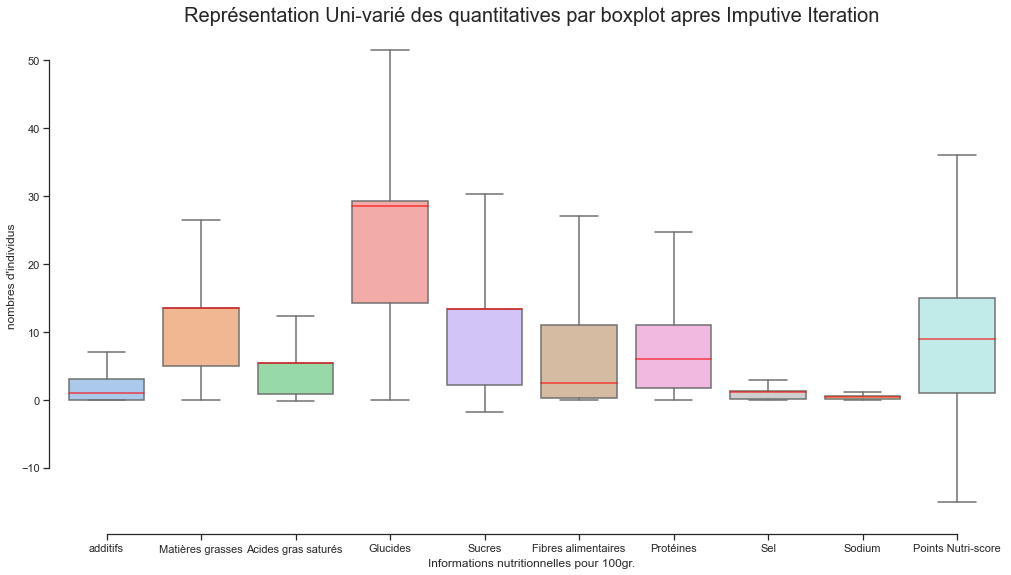

In [164]:
data_oqi = off_quantitative_iter.drop(columns=['code','energy_100g','ingredients_that_may_be_from_palm_oil_n','ingredients_from_palm_oil_n'])
label_x=["additifs","Matières grasses","Acides gras saturés ","Glucides","Sucres","Fibres alimentaires","Protéines","Sel","Sodium",'Points Nutri-score']
sns.set_theme(style="ticks", palette="pastel")

fig, ax = plt.subplots(figsize=(15, 6))
fig.canvas.manager.set_window_title('A Boxplot Quantitative uni-variate')
fig.subplots_adjust(left=0.075, right=0.95, top=1.9, bottom=.75)

# Initialize the figure with a logarithmic y axis
# ax.set_yscale("log")
ax.xaxis.grid(True, linestyle='-', which='major', color='lightgrey',
               alpha=0.5)
ax.set(xlabel="Informations nutritionnelles pour 100gr." , ylabel="nombres d'individus")
# ax.set_xscale(rt)
boxplot_num = sns.boxplot(data=data_oqi, medianprops=dict(color="red", alpha=0.7),showfliers=False)
# stripplot_num = sns.stripplot(data=data_oqi,jitter=0.0001,palette="Set2", size=4, marker="D",
#                    edgecolor="gray", alpha=.25, linewidth=1)
boxplot_num.set_title("Représentation Uni-varié des quantitatives par boxplot apres Imputive Iteration", fontsize=20)
boxplot_num.set_xticklabels(label_x, rotation=30, fontsize=10)
sns.despine(offset=10, trim=True)

In [165]:
from sklearn.impute import SimpleImputer

In [166]:
off_quantitative_tp = off_quantitative_replace.join(off_drop_ref.nutrition_grade_fr.dropna()).copy()

# imputation par la moyenne: les NaN sont remplacés par la moyenne
data_missing=off_quantitative_tp.drop(columns=['code','additives_n',"ingredients_from_palm_oil_n","ingredients_that_may_be_from_palm_oil_n",'nutrition_grade_fr'])
imp = SimpleImputer(missing_values=np.nan, strategy='mean')
data_imputed_brut = imp.fit_transform(data_missing)
data_imputed = pa.DataFrame(data_imputed_brut, columns=[off_quantitative_tp.columns[4:14,]])
data_imputed

,energy_100g,fat_100g,saturated_fat_100g,carbohydrates_100g,sugars_100g,fiber_100g,proteins_100g,salt_100g,sodium_100g,nutrition_score_fr_100g
0,1172.311792,13.400099,5.430233,27.869274,13.434833,15.5872,7.798353,1.288057,0.453346,8.689712
1,1172.311792,13.400099,5.430233,27.869274,13.434833,15.5872,7.798353,1.288057,0.453346,8.689712
2,1172.311792,13.400099,5.430233,27.869274,13.434833,15.5872,7.798353,1.288057,0.453346,8.689712
3,1883.000000,20.000000,12.500000,70.000000,57.500000,2.5000,2.500000,0.096520,0.038000,22.000000
4,1172.311792,13.400099,5.430233,27.869274,13.434833,15.5872,7.798353,1.288057,0.453346,8.689712
...,...,...,...,...,...,...,...,...,...,...
89626,1172.311792,13.400099,5.430233,27.869274,13.434833,15.5872,7.798353,1.288057,0.453346,8.689712
89627,21.000000,0.200000,0.200000,0.500000,0.500000,0.2000,0.500000,0.025400,0.010000,2.000000
89628,1172.311792,13.400099,5.430233,27.869274,13.434833,15.5872,7.798353,1.288057,0.453346,8.689712
89629,1172.311792,13.400099,5.430233,27.869274,13.434833,15.5872,7.798353,1.288057,0.453346,8.689712


In [167]:
missing_samples = data_missing.isna().to_numpy()
missing_samples

array([[ True,  True,  True, ...,  True,  True,  True],
       [ True,  True,  True, ...,  True,  True,  True],
       [ True,  True,  True, ...,  True,  True,  True],
       ...,
       [ True,  True,  True, ...,  True,  True,  True],
       [ True,  True,  True, ...,  True,  True,  True],
       [ True,  True,  True, ...,  True,  True,  True]])

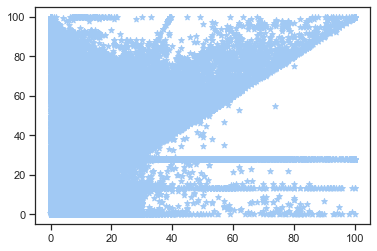

In [168]:
y_col = ['fat_100g','carbohydrates_100g','fiber_100g','salt_100g']
x_col = ['saturated_fat_100g','sugars_100g','proteins_100g','sodium_100g']
# plt.subplots(figsize=(15, 6))
plt.scatter(data_missing[x_col],data_imputed[y_col], marker='*')
plt.show()

In [169]:
imp = SimpleImputer(missing_values=np.nan, strategy='mean')
data_imputed = imp.fit_transform(data_missing)

In [170]:
# obtenir le tableau composé des seules observations complètes
# ~ permet d'inverser un tableau de booléens
my_column = ['fat_100g','saturated_fat_100g']
data_filtered = data_missing[my_column].dropna()
data_filtered

,fat_100g,saturated_fat_100g
106,20.0,12.50
226,0.0,0.00
240,0.0,0.00
242,23.0,2.50
279,19.0,2.50
...,...,...
320670,2.1,1.20
320681,1.3,1.28
320702,1.3,1.28
320751,2.8,0.60


In [171]:
# application de la classification automatique aux observations complètes
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=6).fit(data_filtered)
# affichage des centres obtenus pour les groupes
centers = kmeans.cluster_centers_
print("Centres : {}".format(centers))
c = pa.DataFrame([kmeans.labels_])

Centres : [[ 2.18444443  0.73536578]
 [43.63580334 17.11570644]
 [13.13318151  4.72220467]
 [87.36043896  9.9472533 ]
 [26.54566706 12.51776731]
 [81.00606707 57.70762195]]


In [172]:
centers[:,6:10]

array([], shape=(6, 0), dtype=float64)

In [173]:
np.size(centers[:,0:len(centers)])

12

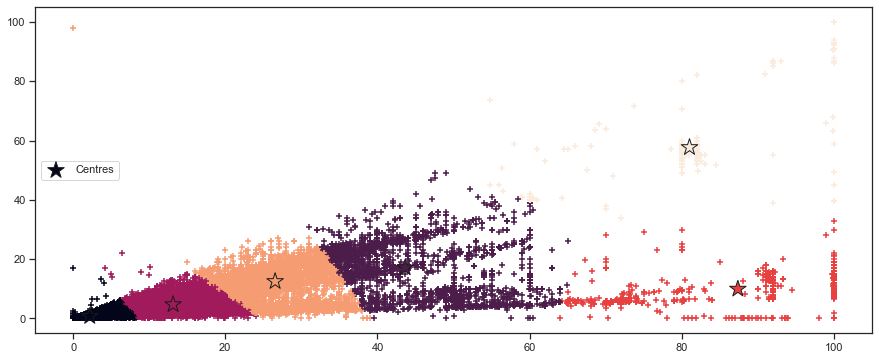

In [174]:
plt.subplots(figsize=(15, 6))
plt.scatter(data_filtered.iloc[:,0], data_filtered.iloc[:,1], marker='+', c=kmeans.labels_)
plt.scatter(centers[:,0], centers[:,1], edgecolors='k', s=300, marker='*', label="Centres", c=range(len(centers)))
plt.legend()
plt.show()

In [175]:
from sklearn.impute import KNNImputer
# imputation sur la base des 3 plus proches voisins sans données manquantes
#  obtenus à partir de distances calculées avec les seules données présentes
data_imputed = KNNImputer(missing_values=np.nan, n_neighbors=3).fit_transform(data_missing)

In [176]:
data_imputed

array([[1.17231179e+03, 1.34000992e+01, 5.43023279e+00, ...,
        1.28805683e+00, 4.53345869e-01, 8.68971196e+00],
       [1.17231179e+03, 1.34000992e+01, 5.43023279e+00, ...,
        1.28805683e+00, 4.53345869e-01, 8.68971196e+00],
       [1.17231179e+03, 1.34000992e+01, 5.43023279e+00, ...,
        1.28805683e+00, 4.53345869e-01, 8.68971196e+00],
       ...,
       [1.17231179e+03, 1.34000992e+01, 5.43023279e+00, ...,
        1.28805683e+00, 4.53345869e-01, 8.68971196e+00],
       [1.17231179e+03, 1.34000992e+01, 5.43023279e+00, ...,
        1.28805683e+00, 4.53345869e-01, 8.68971196e+00],
       [1.17231179e+03, 1.34000992e+01, 5.43023279e+00, ...,
        1.28805683e+00, 4.53345869e-01, 8.68971196e+00]])

<LOCAL_PATH>\AppData\Local\Temp/ipykernel_10148/764321601.py:2: UserWarning: You passed a edgecolor/edgecolors ('k') for an unfilled marker ('+').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  plt.scatter(data_imputed[:,1], data_imputed[:,2], marker='+', edgecolors='k', s=100, c=missing_samples[:,0])


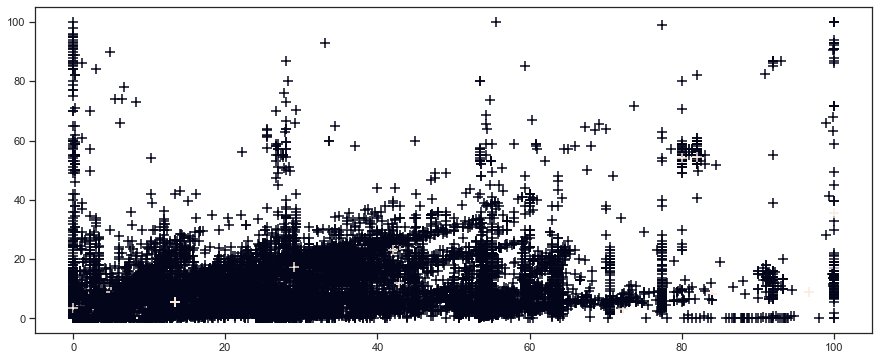

In [177]:
plt.subplots(figsize=(15, 6))
plt.scatter(data_imputed[:,1], data_imputed[:,2], marker='+', edgecolors='k', s=100, c=missing_samples[:,0])
plt.show()

In [178]:
data_imputed = pa.DataFrame(data_imputed_brut, columns=[off_quantitative_tp.columns[4:14,]])
data_imputed.iloc[:,1:10]

,fat_100g,saturated_fat_100g,carbohydrates_100g,sugars_100g,fiber_100g,proteins_100g,salt_100g,sodium_100g,nutrition_score_fr_100g
0,13.400099,5.430233,27.869274,13.434833,15.5872,7.798353,1.288057,0.453346,8.689712
1,13.400099,5.430233,27.869274,13.434833,15.5872,7.798353,1.288057,0.453346,8.689712
2,13.400099,5.430233,27.869274,13.434833,15.5872,7.798353,1.288057,0.453346,8.689712
3,20.000000,12.500000,70.000000,57.500000,2.5000,2.500000,0.096520,0.038000,22.000000
4,13.400099,5.430233,27.869274,13.434833,15.5872,7.798353,1.288057,0.453346,8.689712
...,...,...,...,...,...,...,...,...,...
89626,13.400099,5.430233,27.869274,13.434833,15.5872,7.798353,1.288057,0.453346,8.689712
89627,0.200000,0.200000,0.500000,0.500000,0.2000,0.500000,0.025400,0.010000,2.000000
89628,13.400099,5.430233,27.869274,13.434833,15.5872,7.798353,1.288057,0.453346,8.689712
89629,13.400099,5.430233,27.869274,13.434833,15.5872,7.798353,1.288057,0.453346,8.689712


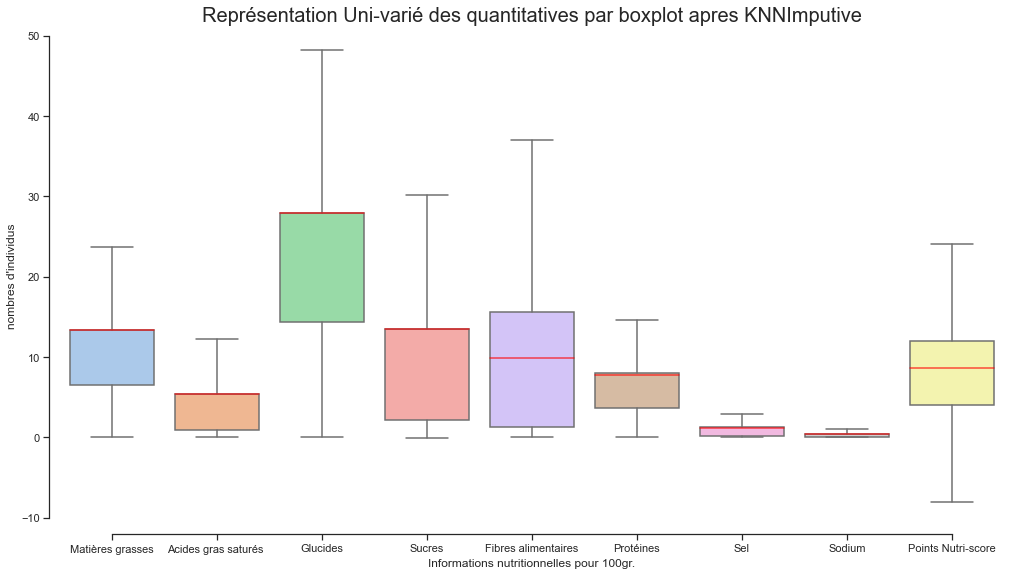

In [179]:
data_knn = data_imputed.iloc[:,1:10]
label_x=["Matières grasses","Acides gras saturés ","Glucides","Sucres","Fibres alimentaires","Protéines","Sel","Sodium",'Points Nutri-score']
sns.set_theme(style="ticks", palette="pastel")

fig, ax = plt.subplots(figsize=(15, 6))
fig.canvas.manager.set_window_title('A Boxplot Quantitative uni-variate')
fig.subplots_adjust(left=0.075, right=0.95, top=1.9, bottom=.75)

# Initialize the figure with a logarithmic y axis
# ax.set_yscale("log")
ax.xaxis.grid(True, linestyle='-', which='major', color='lightgrey',
               alpha=0.5)
ax.set(xlabel="Informations nutritionnelles pour 100gr." , ylabel="nombres d'individus")
# ax.set_xscale(rt)
boxplot_num = sns.boxplot(data=data_knn, medianprops=dict(color="red", alpha=0.7),showfliers=False)
# stripplot_num = sns.stripplot(data=data_oqi,jitter=0.0001,palette="Set2", size=4, marker="D",
#                    edgecolor="gray", alpha=.25, linewidth=1)
boxplot_num.set_title("Représentation Uni-varié des quantitatives par boxplot apres KNNImputive", fontsize=20)
boxplot_num.set_xticklabels(label_x, rotation=30, fontsize=10)
sns.despine(offset=10, trim=True)

In [180]:
estimated = data_missing.fillna(0)
print(estimated)

        energy_100g  fat_100g  saturated_fat_100g  carbohydrates_100g  \
0               0.0       0.0                 0.0                 0.0   
46              0.0       0.0                 0.0                 0.0   
48              0.0       0.0                 0.0                 0.0   
106          1883.0      20.0                12.5                70.0   
136             0.0       0.0                 0.0                 0.0   
...             ...       ...                 ...                 ...   
320761          0.0       0.0                 0.0                 0.0   
320763         21.0       0.2                 0.2                 0.5   
320764          0.0       0.0                 0.0                 0.0   
320765          0.0       0.0                 0.0                 0.0   
320770          0.0       0.0                 0.0                 0.0   

        sugars_100g  fiber_100g  proteins_100g  salt_100g  sodium_100g  \
0               0.0         0.0            0.0   

In [181]:
from sklearn.metrics import mean_squared_error
from sklearn.neighbors import NearestCentroid

y = np.array([1, 2, 3])    # les étiquettes des groupes
ncPredictor = NearestCentroid()

# les centres calculés par k-means sont associés aux 3 étiquettes des groupes
#  (les 'observations' pour NearestCentroid sont les centres issus de k-means)
#   seules les coordonnées des centres sur l'axe 1 sont employées
ncPredictor.fit(centers[:,0].reshape(-1, 1), y)

# l'index du centre le plus proche est déterminé pour chaque observation à
#  donnée manquante (à partir de la valeur de la variable non manquante, axe 1
nearest = ncPredictor.predict(data_missing[missing_samples, 0].reshape(-1,1))
# détermination des valeurs à utiliser pour l'imputation : pour chaque
#  observation, la valeur sur l'axe 2 du centre correspondant
estimated = data_missing.fillna(0)
indices = range(data_missing)
for i in indices:
    estimated[i] = centers[nearest[i]-1,1]

data_imputed = data_missing.copy()   # initialisation de data_imputed
# imputation avec les valeurs obtenues
data_imputed[missing_samples, 1] = estimated
# calcul de l'erreur moyenne d'imputation
# mean_squared_error(data[missing_samples,1],data_imputed[missing_samples,1])

ValueError: Found input variables with inconsistent numbers of samples: [6, 3]

In [ ]:
plt.scatter(data_imputed[:,0], data_imputed[:,1], marker='+', c=missing_samples)
plt.scatter(centers[:,0], centers[:,1], edgecolors='k', s=300, marker='*', label="Centres", c='r')
plt.legend()
plt.show()

In [ ]:
def calcul_nrj(data,i_rows):
    fat=data.fat_100g[i_rows]
    carbo=data.carbohydrates_100g[i_rows]
    prot=data.proteins_100g[i_rows]
    y = 17 * ((fat * 38 / 17) + carbo + prot)
    return y

In [ ]:
# off_quantitative_replace_nrj = off_quantitative_iter.copy()
# nrj_na = off_quantitative_replace_nrj[off_quantitative_replace_nrj.energy_100g.isna()]
# nrj_na

In [ ]:
# off_quantitative_replace_nrj = off_quantitative_iter.copy()
# nrj_na = off_quantitative_replace_nrj[off_quantitative_replace_nrj.energy_100g.isna()]
# i_nrj_na = nrj_na.index
# calcul_nrj(nrj_na,i_nrj_na)
# # off_quantitative_replace_nrj.energy_100g.fillna(calcul_nrj(nrj_na,i_nrj_na))

In [ ]:
# off_quantitative_replace_nrj

In [ ]:
# off_quantitative_replace_nrj.describe()

In [ ]:
# off_quantitative_replace_nrj.where(off_quantitative_replace_nrj.energy_100g > 2500).dropna(subset=['code'])

In [ ]:
# off.loc[11179]

In [ ]:
# boxplot_c = sns.boxplot(data=off_quantitative_replace_nrj, x='energy_100g', hue ="energy_100g",color='red')
# boxplot_c.set_xlabel("Valeur énergitique (kJoules)", fontsize=20)
# boxplot_c.set_ylabel("nombres d'individus", fontsize=20)
# boxplot_c.set(xscale="log")
#
# plt.title(f"boite à moustache des circonférences par nombres d'individus", fontsize=25)
# plt.gcf().set_size_inches(15,4)
# plt.tight_layout()

In [ ]:
# data = off_quantitative_replace_nrj.drop(columns=['code','ingredients_that_may_be_from_palm_oil_n','ingredients_from_palm_oil_n'])
# histogramme = sns.displot(data=data, x="energy_100g", kde=True, color='green')
# histogramme.set_xlabels("Valeur énergitique (kJoules)", fontsize=20)
# histogramme.set_ylabels("nombres d'individus", fontsize=20)
# plt.title(f"Repartition de la valeur énergétique par nombres d'individus", fontsize=25)
# plt.legend(labels=['Estimation de la densité du noyau','Energie'], fontsize=14)
# plt.gcf().set_size_inches(15,8)
# plt.tight_layout()
# plt.show()

In [1]:
# data = off_quantitative_replace_nrj.drop(columns=['code','energy_100g','ingredients_that_may_be_from_palm_oil_n','ingredients_from_palm_oil_n'])
# histogramme = sns.displot(data=data.fat_100g, kde=True, color='green')
# histogramme.set_xlabels("Valeur énergitique (kJoules)", fontsize=20)
# histogramme.set_ylabels("nombres d'individus", fontsize=20)
# plt.title(f"Repartition de la valeur énergétique par nombres d'individus", fontsize=25)
# plt.legend(labels=['Estimation de la densité du noyau','Energie'], fontsize=14)
# plt.gcf().set_size_inches(15,8)
# plt.tight_layout()
# plt.show()

In [ ]:
off_corr = off.drop(columns=[
    'no_nutriments',
    'ingredients_from_palm_oil',
    'ingredients_that_may_be_from_palm_oil',
    'ingredients_that_may_be_from_palm_oil',
    'nutrition_grade_uk',
    'butyric_acid_100g',
    'caproic_acid_100g',
    'lauric_acid_100g',
    'myristic_acid_100g',
    'palmitic_acid_100g',
    'stearic_acid_100g',
    'arachidic_acid_100g',
    'behenic_acid_100g',
    'lignoceric_acid_100g',
    'cerotic_acid_100g',
    'montanic_acid_100g',
    'caprylic_acid_100g',
    'capric_acid_100g',
    'melissic_acid_100g',
    'gamma_linolenic_acid_100g',
    'dihomo_gamma_linolenic_acid_100g',
    'elaidic_acid_100g',
    'gondoic_acid_100g',
    'mead_acid_100g',
    'erucic_acid_100g',
    'nervonic_acid_100g',
    'chlorophyl_100g',
    'glycemic_index_100g',
    'water_hardness_100g'
])
off_corr.corr()

In [ ]:
off_corr.describe()

In [ ]:
off_seuil = off_corr.corr().apply(lambda x: x > 0.75)

In [ ]:
loc_index = off_seuil.where(off_seuil.sum() > 1).dropna().index

In [ ]:
# off.where().dropna(axis=1)
off_count = off[loc_index].count() > 10000
# off.loc[:,off_count.index]
# [off_count.index if (off_count.value) else np.nan]
off_count = off_count.loc[off_count].index
off_select = off.loc[:,off_count]

In [ ]:
corr_test = off_select.corr()

In [ ]:
mask = np.zeros_like(corr_test)
mask[np.triu_indices_from(mask)] = True
with sns.axes_style("white"):
    fig.suptitle(f"Analyse de corrélation par Heatmap des variables quantitatives", fontsize=25)
    fig.subplots_adjust(top=0.9)
    fig, ax = plt.subplots(figsize=(20,20))
    ax = sns.heatmap(corr_test, mask=mask, vmax=.3, square=True, linewidths=.5, annot=True)
    ax.set_xticklabels(corr_test, rotation=50, fontsize=14)
    ax.set_yticklabels(corr_test, fontsize=14)
    plt.tight_layout()
    plt.show()